# Modeling 

## Libraries

In [1]:
# pip install xgboost
# pip install dbfread

In [2]:
import sys
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import Lasso
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score, median_absolute_error
from sklearn.metrics import confusion_matrix, cohen_kappa_score, roc_auc_score, roc_curve
import xgboost as xgb
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib
import dbfread

from sklearn.preprocessing import StandardScaler
from dbfread import DBF

In [18]:
print(sys.version)

3.10.9 | packaged by Anaconda, Inc. | (main, Mar  1 2023, 18:18:15) [MSC v.1916 64 bit (AMD64)]


In [19]:
print(xgb. __file__)

C:\Users\Welcome\AppData\Roaming\Python\Python310\site-packages\xgboost\__init__.py


In [20]:
print(joblib. __file__)

C:\ProgramData\anaconda3\lib\site-packages\joblib\__init__.py


In [4]:
print(dbfread. __file__)

C:\Users\Welcome\AppData\Roaming\Python\Python310\site-packages\dbfread\__init__.py


In [5]:
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


## Basic: Data Viewing, Tabulation and Statistics

In [6]:
a = pd.read_csv('GullyInputs.csv')

In [7]:
df = a.drop(['Class'],axis =1)


In [8]:
df

,TWI,SPI,NDVI,DrDensity,DistToRoad,DistToRive,SoilTextur,SoilOrder,LULC,Geology,DEM,TPI,SlopeDeg,Rainfall
0,3.78828,1.560250,0.788350,1942.57,2600.470,988.661,Sand,Entisols,Forest,Lk,1626.160,-10.46580,36.760600,1512.84
1,4.86913,1.242830,0.677790,2785.19,2580.550,392.173,Loamy Sand,Inceptisols,Forest,Lk,1613.420,7.04517,30.245900,1520.52
2,5.12602,-0.109587,0.559909,2185.60,2149.040,637.377,Loamy Sand,Inceptisols,Agriculture- Sloping Terrace,Sy,1461.230,2.05237,18.061200,1541.74
3,3.10745,0.295735,0.658635,1827.47,2040.350,783.613,Loamy Sand,Inceptisols,Agriculture- Sloping Terrace,Sy,1400.530,3.13489,29.734800,1545.52
4,7.52540,4.886550,0.737690,2062.17,1769.550,468.108,Loamy Sand,Inceptisols,Agriculture- Sloping Terrace,Sy,1219.760,-15.16760,18.144300,1555.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,12.40620,-3.061730,0.333061,4224.42,524.169,300.541,Clay Loam,Entisols,"Agriculture- Valley, Tar, Terai",Ls,628.261,-1.41974,0.119773,1724.05
422,4.86786,-10.140500,0.645071,5465.20,202.581,375.832,Clay Loam,Entisols,"Agriculture- Valley, Tar, Terai",Ls,626.298,-1.70160,0.762268,1721.14
423,4.19804,-0.791919,0.494478,4832.55,368.734,395.601,Loamy Sand,Entisols,"Agriculture- Valley, Tar, Terai",Ls,655.349,-1.05829,4.618240,1719.27
424,4.35895,-0.952054,0.699133,3426.64,1599.490,1204.000,Loamy Sand,Entisols,Forest,Ls,740.193,-5.99628,14.994600,1729.59


In [9]:
df.shape

(426, 14)

In [10]:
df.columns

Index(['TWI', 'SPI', 'NDVI', 'DrDensity', 'DistToRoad', 'DistToRive',
       'SoilTextur', 'SoilOrder', 'LULC', 'Geology', 'DEM', 'TPI', 'SlopeDeg',
       'Rainfall'],
      dtype='object')

In [11]:
df.values

array([[3.78828, 1.56025, 0.78835, ..., -10.4658, 36.7606, 1512.84],
       [4.86913, 1.24283, 0.67779, ..., 7.04517, 30.2459, 1520.52],
       [5.12602, -0.109587, 0.559909, ..., 2.05237, 18.0612, 1541.74],
       ...,
       [4.19804, -0.791919, 0.494478, ..., -1.05829, 4.61824, 1719.27],
       [4.35895, -0.952054, 0.699133, ..., -5.99628, 14.9946, 1729.59],
       [2.66078, -7.95624, 0.51337, ..., 7.53229, 15.7705, 1718.33]],
      dtype=object)

In [12]:
df.describe()


,TWI,SPI,NDVI,DrDensity,DistToRoad,DistToRive,DEM,TPI,SlopeDeg,Rainfall
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000
mean,7.277534,-3.333346,0.483628,3791.854075,370.246578,527.785173,709.916991,-0.122553,5.536212,1697.500610
std,3.403660,4.696342,0.145547,1188.173797,410.462623,388.754386,202.838838,3.056263,9.769742,53.709544
min,2.660780,-13.779200,-0.337004,492.556000,0.000000,0.000000,567.062000,-16.091900,0.050946,1512.840000
25%,4.830602,-6.043560,0.384937,3041.962500,103.305500,242.318250,604.579250,-0.814056,0.693240,1657.150000
50%,6.182245,-2.091630,0.481544,3570.875000,226.931500,458.187000,641.458500,-0.135987,1.289795,1700.395000
75%,9.059140,0.031587,0.574096,4418.112500,498.451250,725.002750,693.276500,0.704773,3.906928,1741.385000
max,21.153900,6.305520,0.802033,7959.440000,2600.470000,1983.540000,1699.620000,19.896100,43.237700,1804.990000


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TWI         426 non-null    float64
 1   SPI         426 non-null    float64
 2   NDVI        426 non-null    float64
 3   DrDensity   426 non-null    float64
 4   DistToRoad  426 non-null    float64
 5   DistToRive  426 non-null    float64
 6   SoilTextur  426 non-null    object 
 7   SoilOrder   426 non-null    object 
 8   LULC        426 non-null    object 
 9   Geology     426 non-null    object 
 10  DEM         426 non-null    float64
 11  TPI         426 non-null    float64
 12  SlopeDeg    426 non-null    float64
 13  Rainfall    426 non-null    float64
dtypes: float64(10), object(4)
memory usage: 46.7+ KB
None


## Data Cleaning

### Check for missing or null values

In [14]:
df.isna().sum()

TWI           0
SPI           0
NDVI          0
DrDensity     0
DistToRoad    0
DistToRive    0
SoilTextur    0
SoilOrder     0
LULC          0
Geology       0
DEM           0
TPI           0
SlopeDeg      0
Rainfall      0
dtype: int64

In [16]:
df.isna()

,TWI,SPI,NDVI,DrDensity,DistToRoad,DistToRive,SoilTextur,SoilOrder,LULC,Geology,DEM,TPI,SlopeDeg,Rainfall
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,False,False,False,False,False,False,False,False,False,False,False,False,False,False
422,False,False,False,False,False,False,False,False,False,False,False,False,False,False
423,False,False,False,False,False,False,False,False,False,False,False,False,False,False
424,False,False,False,False,False,False,False,False,False,False,False,False,False,False


### Check for duplicate values

In [17]:
df.duplicated().sum()

0

In [18]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
421    False
422    False
423    False
424    False
425    False
Length: 426, dtype: bool

### Outlier

#### Plotting the data as it is

Index(['TWI', 'SPI', 'NDVI', 'DrDensity', 'DistToRoad', 'DistToRive',
       'SoilTextur', 'SoilOrder', 'LULC', 'Geology', 'DEM', 'TPI', 'SlopeDeg',
       'Rainfall'],
      dtype='object')
Plot saved as Histogram of GES factors before normalization.jpg


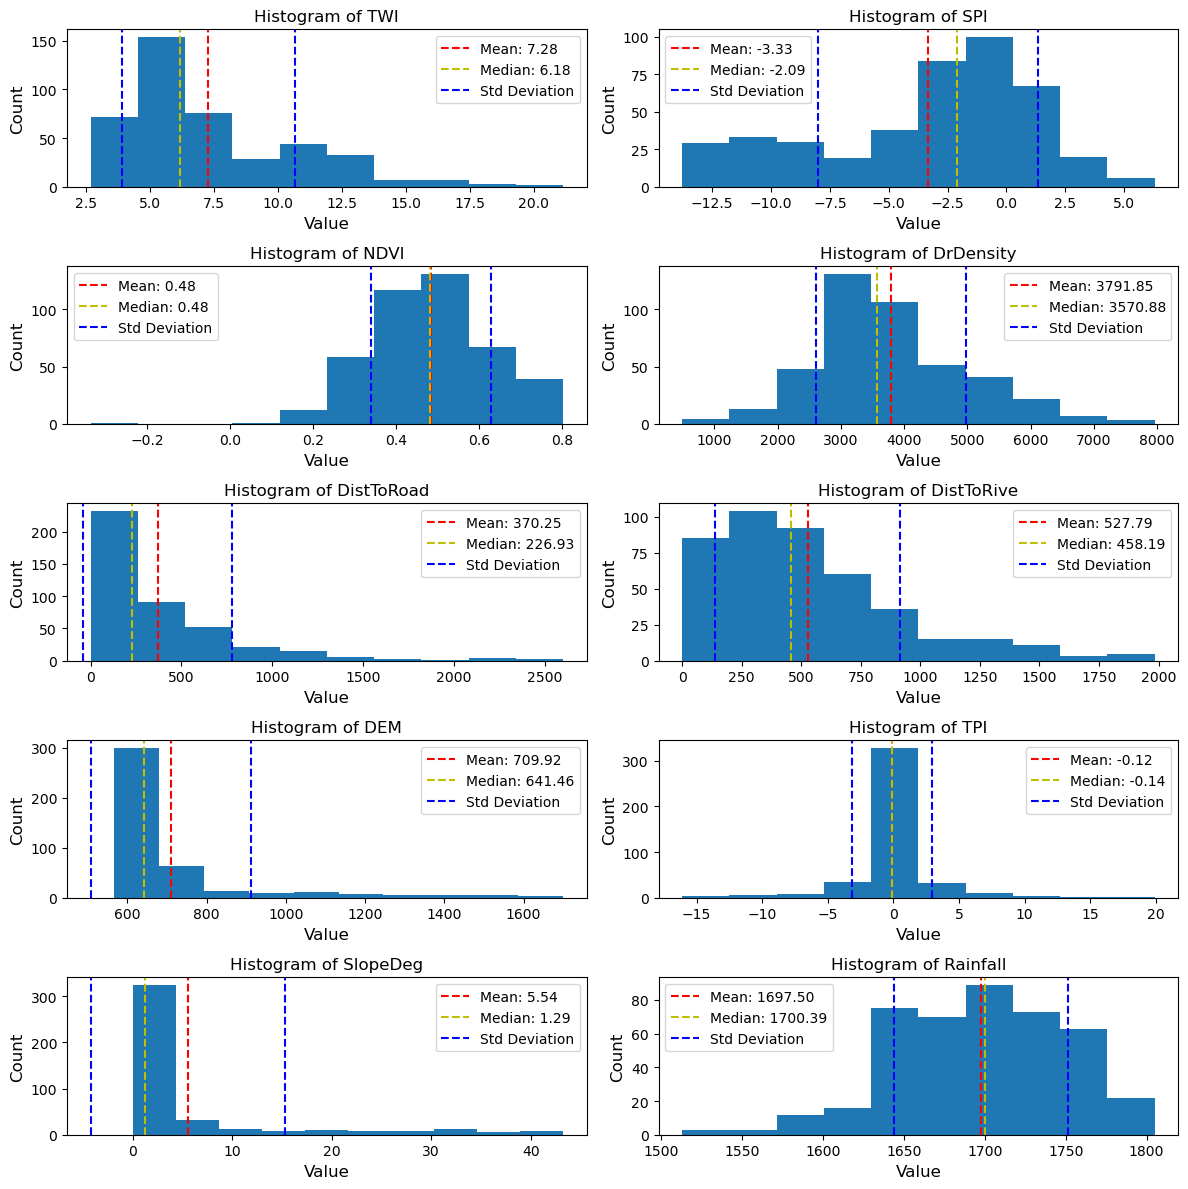

In [21]:
# Get the feature names
features = df.columns[:]

print(features)

# Filter out numerical features excluding "Class"
numerical_features= df.select_dtypes(include=[np.number]).columns

# Define the number of subplots (3 by 3 matrix)
num_rows = 5
num_cols = 2
num_subplots = min(len(numerical_features), num_rows * num_cols)

# Create the subplots dynamically
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 12))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through each numerical feature
for i, feature in enumerate(numerical_features[:num_subplots]):
    # Plot histogram on each subplot
    axes[i].hist(df[feature], bins=10)
    axes[i].set_title('Histogram of {}'.format(feature))
    
    # Customize subplot layout
    axes[i].set_xlabel('Value', fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    
    # Calculate mean, median, and standard deviation
    mean_val = np.mean(df[feature])
    median_val = np.median(df[feature])
    std_val = np.std(df[feature])
    
    # Draw mean, median, and standard deviation lines
    axes[i].axvline(mean_val, color='r', linestyle='--', label='Mean: {:.2f}'.format(mean_val))
    axes[i].axvline(median_val, color='y', linestyle='--', label='Median: {:.2f}'.format(median_val))
    axes[i].axvline(mean_val - std_val, color='b', linestyle='--', label='Std Deviation')
    axes[i].axvline(mean_val + std_val, color='b', linestyle='--')
    
    # Add legend
    axes[i].legend()

# Adjust the spacing between subplots
plt.tight_layout()

# Save the plot to a file (before plt.show())
output_filename = "Histogram of GES factors before normalization.jpg"  # or .pdf, .svg
plt.savefig(output_filename, dpi=450, bbox_inches='tight')
print(f"Plot saved as {output_filename}")

# Show the plot
plt.show()


#### Z-Scores (Scaling/Standarizing) calculation and outlier detection


In [22]:
# # Filter out numerical features
# numerical_features = df.select_dtypes(include=[np.number])
# print ('The numerical features are: \n',numerical_features)

# # Calculate z-scores for each numerical feature
# z_scores = pd.DataFrame(np.abs(stats.zscore(numerical_features)), columns=numerical_features.columns)

# print('The Z-scores for the numerical features are: \n',z_scores)

# # Set the threshold for outlier detection
# threshold = 3

# # Detect outliers for each numerical feature
# outliers = (z_scores > threshold)

# # Print the table of feature outliers and their z-scores
# for feature in outliers.columns:
#     feature_outliers = z_scores.loc[outliers[feature], feature]
#     if not feature_outliers.empty:
#         print(f"\nOutliers for feature in z-score for '{feature}':\n")
#         print(feature_outliers)
#         print(feature_outliers.shape)       

# Filter out numerical features
numerical_features = df.select_dtypes(include=[np.number])
print('The numerical features are:\n', numerical_features)

# Calculate z-scores for each numerical feature
z_scores = pd.DataFrame(np.abs(stats.zscore(numerical_features)), columns=numerical_features.columns)
print('The Z-scores for the numerical features are:\n', z_scores)

# Set the thresholds for outlier detection
threshold_positive = 3
threshold_negative = -3

# Detect outliers for each numerical feature using both thresholds
outliers_positive = (z_scores > threshold_positive)
outliers_negative = (z_scores < threshold_negative)

# Combine positive and negative outliers
outliers = outliers_positive | outliers_negative

# Print the table of feature outliers and their z-scores for both thresholds
for feature in outliers.columns:
    feature_outliers = z_scores.loc[outliers[feature], feature]
    if not feature_outliers.empty:
        print(f"\nOutliers for z-score in '{feature}' (Thresholds: +{threshold_positive}, {threshold_negative}):\n")
        print(feature_outliers)
        print("Number of outliers:", feature_outliers.shape[0])


The numerical features are:
           TWI        SPI      NDVI  DrDensity  DistToRoad  DistToRive  \
0     3.78828   1.560250  0.788350    1942.57    2600.470     988.661   
1     4.86913   1.242830  0.677790    2785.19    2580.550     392.173   
2     5.12602  -0.109587  0.559909    2185.60    2149.040     637.377   
3     3.10745   0.295735  0.658635    1827.47    2040.350     783.613   
4     7.52540   4.886550  0.737690    2062.17    1769.550     468.108   
..        ...        ...       ...        ...         ...         ...   
421  12.40620  -3.061730  0.333061    4224.42     524.169     300.541   
422   4.86786 -10.140500  0.645071    5465.20     202.581     375.832   
423   4.19804  -0.791919  0.494478    4832.55     368.734     395.601   
424   4.35895  -0.952054  0.699133    3426.64    1599.490    1204.000   
425   2.66078  -7.956240  0.513370    4519.72     534.953     833.442   

          DEM       TPI   SlopeDeg  Rainfall  
0    1626.160 -10.46580  36.760600   1512.84  


In [23]:
# Filter out outliers from the z-scores table
z_scores_no_outliers = z_scores.mask(outliers)

# Add categorical features to the z-scores table
categorical_features = df.select_dtypes(include=[object])
z_scores_no_outliers = pd.concat([a['Class'], categorical_features, z_scores_no_outliers], axis=1)

# Print the table of z-scores without outliers
print(z_scores_no_outliers)


     Class  SoilTextur    SoilOrder                             LULC Geology  \
0        1        Sand     Entisols                           Forest      Lk   
1        0  Loamy Sand  Inceptisols                           Forest      Lk   
2        0  Loamy Sand  Inceptisols     Agriculture- Sloping Terrace      Sy   
3        1  Loamy Sand  Inceptisols     Agriculture- Sloping Terrace      Sy   
4        0  Loamy Sand  Inceptisols     Agriculture- Sloping Terrace      Sy   
..     ...         ...          ...                              ...     ...   
421      0   Clay Loam     Entisols  Agriculture- Valley, Tar, Terai      Ls   
422      0   Clay Loam     Entisols  Agriculture- Valley, Tar, Terai      Ls   
423      0  Loamy Sand     Entisols  Agriculture- Valley, Tar, Terai      Ls   
424      0  Loamy Sand     Entisols                           Forest      Ls   
425      0  Loamy Sand     Entisols  Agriculture- Valley, Tar, Terai      Ls   

          TWI       SPI      NDVI  DrDe

In [24]:
z_scores_no_outliers.isna().sum()

Class          0
SoilTextur     0
SoilOrder      0
LULC           0
Geology        0
TWI            5
SPI            0
NDVI           1
DrDensity      3
DistToRoad     9
DistToRive     6
DEM           15
TPI           13
SlopeDeg      14
Rainfall       2
dtype: int64

#### Removing Outliers and Saving Clean Input Data

In [25]:
# Drop rows with NaN values
z_scores_no_outliers_rows = z_scores_no_outliers.dropna()

# Print the table of z-scores without outlier rows and without NaN values
print(type(z_scores_no_outliers_rows))
print(z_scores_no_outliers_rows)


# Export the z-scores without outliers rows to a CSV file
z_scores_no_outliers_rows.to_csv('z_scores_no_outliers_rows.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
     Class  SoilTextur    SoilOrder                             LULC Geology  \
7        0  Loamy Sand  Inceptisols                           Forest      Sy   
8        1  Sandy Loam     Alfisols  Agriculture- Valley, Tar, Terai      Sy   
9        1  Sandy Loam     Alfisols  Agriculture- Valley, Tar, Terai      Sy   
10       1  Sandy Loam     Alfisols  Agriculture- Valley, Tar, Terai      Sy   
11       1  Sandy Loam     Alfisols  Agriculture- Valley, Tar, Terai      Sy   
..     ...         ...          ...                              ...     ...   
421      0   Clay Loam     Entisols  Agriculture- Valley, Tar, Terai      Ls   
422      0   Clay Loam     Entisols  Agriculture- Valley, Tar, Terai      Ls   
423      0  Loamy Sand     Entisols  Agriculture- Valley, Tar, Terai      Ls   
424      0  Loamy Sand     Entisols                           Forest      Ls   
425      0  Loamy Sand     Entisols  Agriculture- Valley, Tar, Terai      Ls   

 

#### Plotting normalized numerical features

Index(['Class', 'SoilTextur', 'SoilOrder', 'LULC', 'Geology', 'TWI', 'SPI',
       'NDVI', 'DrDensity', 'DistToRoad', 'DistToRive', 'DEM', 'TPI',
       'SlopeDeg', 'Rainfall'],
      dtype='object')
Plot saved as Histogram of GES factors after normalization.jpg


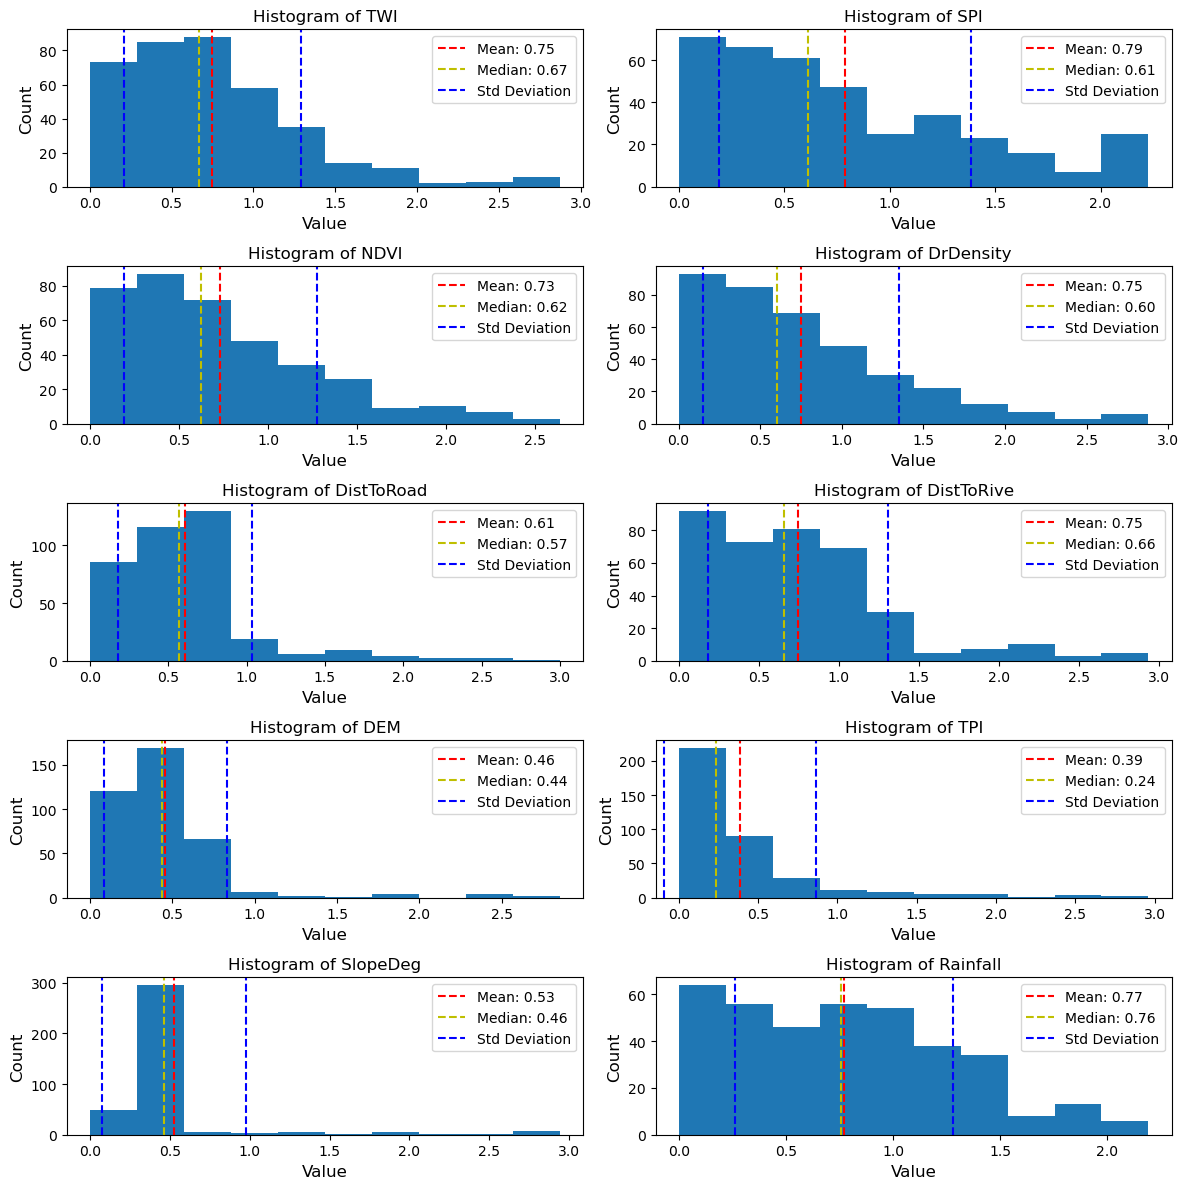

In [28]:
# Get the feature names
features1 = z_scores_no_outliers_rows.columns[:]

print(features1)

# Get the feature names
features1 = z_scores_no_outliers_rows.columns

# Filter out numerical features excluding "Class"
numerical_features1 = z_scores_no_outliers_rows.select_dtypes(include=[np.number]).columns
numerical_features1 = numerical_features1[numerical_features1 != 'Class']

# Define the number of subplots (3 by 3 matrix)
num_rows = 5
num_cols = 2
num_subplots = min(len(numerical_features1), num_rows * num_cols)

# Create the subplots dynamically
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 12))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through each numerical feature
for i, feature in enumerate(numerical_features1[:num_subplots]):
    # Plot histogram on each subplot
    axes[i].hist(z_scores_no_outliers_rows[feature], bins=10)
    axes[i].set_title('Histogram of {}'.format(feature))
    
    # Customize subplot layout
    axes[i].set_xlabel('Value', fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    
    # Calculate mean, median, and standard deviation
    mean_val = np.mean(z_scores_no_outliers_rows[feature])
    median_val = np.median(z_scores_no_outliers_rows[feature])
    std_val = np.std(z_scores_no_outliers_rows[feature])
    
    # Draw mean, median, and standard deviation lines
    axes[i].axvline(mean_val, color='r', linestyle='--', label='Mean: {:.2f}'.format(mean_val))
    axes[i].axvline(median_val, color='y', linestyle='--', label='Median: {:.2f}'.format(median_val))
    axes[i].axvline(mean_val - std_val, color='b', linestyle='--', label='Std Deviation')
    axes[i].axvline(mean_val + std_val, color='b', linestyle='--')
    
    # Add legend
    axes[i].legend()

# Adjust the spacing between subplots
plt.tight_layout()

# Save the plot to a file (before plt.show())
output_filename = "Histogram of GES factors after normalization.jpg"  # or .pdf, .svg
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved as {output_filename}")

# Show the plot
plt.show()


In [29]:
z_scores_no_outliers_rows.describe()

,Class,TWI,SPI,NDVI,DrDensity,DistToRoad,DistToRive,DEM,TPI,SlopeDeg,Rainfall
count,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000,375.000000
mean,0.533333,0.748558,0.786935,0.731109,0.751725,0.606798,0.745243,0.457949,0.385757,0.525804,0.770460
std,0.499554,0.541474,0.598941,0.542432,0.599881,0.426651,0.564972,0.375326,0.478599,0.449984,0.511192
min,0.000000,0.004061,0.001271,0.000827,0.002927,0.002948,0.000140,0.001782,0.000958,0.000456,0.000198
25%,0.000000,0.336417,0.300993,0.310010,0.296104,0.337766,0.306251,0.242539,0.099632,0.378884,0.309806
50%,1.000000,0.666073,0.610597,0.624064,0.602879,0.568245,0.656651,0.437279,0.235048,0.461377,0.756795
75%,1.000000,0.997652,1.205365,1.046736,1.102195,0.775498,1.034876,0.565911,0.446086,0.520377,1.120006
max,1.000000,2.869745,2.226869,2.639862,2.878200,2.998297,2.935697,2.852030,2.960312,2.942345,2.191768


In [30]:
a.describe()

,Class,TWI,SPI,NDVI,DrDensity,DistToRoad,DistToRive,DEM,TPI,SlopeDeg,Rainfall
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000
mean,0.500000,7.277534,-3.333346,0.483628,3791.854075,370.246578,527.785173,709.916991,-0.122553,5.536212,1697.500610
std,0.500588,3.403660,4.696342,0.145547,1188.173797,410.462623,388.754386,202.838838,3.056263,9.769742,53.709544
min,0.000000,2.660780,-13.779200,-0.337004,492.556000,0.000000,0.000000,567.062000,-16.091900,0.050946,1512.840000
25%,0.000000,4.830602,-6.043560,0.384937,3041.962500,103.305500,242.318250,604.579250,-0.814056,0.693240,1657.150000
50%,0.500000,6.182245,-2.091630,0.481544,3570.875000,226.931500,458.187000,641.458500,-0.135987,1.289795,1700.395000
75%,1.000000,9.059140,0.031587,0.574096,4418.112500,498.451250,725.002750,693.276500,0.704773,3.906928,1741.385000
max,1.000000,21.153900,6.305520,0.802033,7959.440000,2600.470000,1983.540000,1699.620000,19.896100,43.237700,1804.990000


##  Feature Importance Score, Feature Selection and Ranking 

### One-Hot Encoding

#### One Hot encoding of Categorical Features

In [31]:
# Read the exported CSV file into a DataFrame
input1 = pd.read_csv('z_scores_no_outliers_rows.csv')

# Get the categorical features
categorical_features = input1.select_dtypes(include=[object])

# Perform one-hot encoding
encoder = OneHotEncoder()
encoded_features = encoder.fit_transform(categorical_features)

# Create a DataFrame from the encoded features
encoded_df = pd.DataFrame(encoded_features.toarray(), columns=encoder.get_feature_names_out(categorical_features.columns))

# Concatenate the encoded features with the numerical features
input1_OneHotencoded = pd.concat([input1.drop(categorical_features.columns, axis=1), encoded_df], axis=1)

input1_OneHotencoded

,Class,TWI,SPI,NDVI,DrDensity,DistToRoad,DistToRive,DEM,TPI,SlopeDeg,...,LULC_Forest,LULC_Residential,LULC_Sand/Gravel/Boulders,LULC_Shrubland/Grassland,Geology_Ks,Geology_Lk,Geology_Ls,Geology_Q,Geology_Sw,Geology_Sy
0,0,0.637432,1.272572,2.122400,0.529017,1.739018,0.634233,1.720296,0.387681,2.901887,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,0.072855,1.027479,0.930965,0.848445,0.963532,0.263798,1.072800,1.405799,0.464436,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1,0.267802,2.048883,0.974218,0.976657,0.486939,0.673852,1.020940,1.986084,0.000739,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,0.197592,0.918623,1.223214,1.160272,0.087947,0.411587,0.894425,0.147657,0.094445,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1,0.038896,0.799498,1.356874,1.250727,0.166070,0.534716,0.860812,0.534141,0.150033,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,0,1.508581,0.057904,1.035709,0.364488,0.375438,0.585232,0.403039,0.424935,0.555061,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
371,0,0.708798,1.451163,1.110520,1.409990,0.408960,0.391331,0.412728,0.517267,0.489220,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
372,0,0.905823,0.541787,0.074633,0.876908,0.003689,0.340420,0.269338,0.306530,0.094071,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
373,0,0.858492,0.507649,1.482397,0.307736,2.998297,1.741485,0.149437,1.924125,0.969269,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### VIF and Tol Calculation after One Hot Encoding

In [32]:
# Calculate VIF and TOL
X = input1_OneHotencoded.drop('Class', axis=1)  # Exclude the 'Class' column
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["TOL"] = 1 / vif["VIF"]

# print VIF and TOL
vif

C:\ProgramData\anaconda3\lib\site-packages\statsmodels\stats\outliers_influence.py:195: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


,Feature,VIF,TOL
0,TWI,1.072764,0.932171
1,SPI,1.085490,0.921243
2,NDVI,1.290751,0.774743
3,DrDensity,1.378153,0.725609
4,DistToRoad,1.205049,0.829842
5,DistToRive,1.149477,0.869961
6,DEM,3.459148,0.289088
7,TPI,1.796200,0.556731
8,SlopeDeg,3.572003,0.279955
9,Rainfall,1.444428,0.692316


### Label Encoding (Used here)

#### Label Encoding of Categorical Features 

In [33]:
# Read the exported CSV file into a DataFrame
input1 = pd.read_csv('z_scores_no_outliers_rows.csv')

# Get the categorical features
categorical_features = input1.select_dtypes(include=[object])

# Perform label encoding
encoder = LabelEncoder()
encoded_features = categorical_features.apply(encoder.fit_transform)

# Concatenate the encoded features with the numerical features
input1_encoded = pd.concat([input1.drop(categorical_features.columns, axis=1), encoded_features], axis=1)

# Print the encoded DataFrame
input1_encoded

,Class,TWI,SPI,NDVI,DrDensity,DistToRoad,DistToRive,DEM,TPI,SlopeDeg,Rainfall,SoilTextur,SoilOrder,LULC,Geology
0,0,0.637432,1.272572,2.122400,0.529017,1.739018,0.634233,1.720296,0.387681,2.901887,1.971809,3,2,2,5
1,1,0.072855,1.027479,0.930965,0.848445,0.963532,0.263798,1.072800,1.405799,0.464436,1.768441,6,0,1,5
2,1,0.267802,2.048883,0.974218,0.976657,0.486939,0.673852,1.020940,1.986084,0.000739,1.736752,6,0,1,5
3,1,0.197592,0.918623,1.223214,1.160272,0.087947,0.411587,0.894425,0.147657,0.094445,1.617080,6,0,1,5
4,1,0.038896,0.799498,1.356874,1.250727,0.166070,0.534716,0.860812,0.534141,0.150033,1.598439,6,0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,0,1.508581,0.057904,1.035709,0.364488,0.375438,0.585232,0.403039,0.424935,0.555061,0.494895,1,1,1,2
371,0,0.708798,1.451163,1.110520,1.409990,0.408960,0.391331,0.412728,0.517267,0.489220,0.440651,1,1,1,2
372,0,0.905823,0.541787,0.074633,0.876908,0.003689,0.340420,0.269338,0.306530,0.094071,0.405794,3,1,1,2
373,0,0.858492,0.507649,1.482397,0.307736,2.998297,1.741485,0.149437,1.924125,0.969269,0.598164,3,1,2,2


#### Plotting the Feature Engineered data

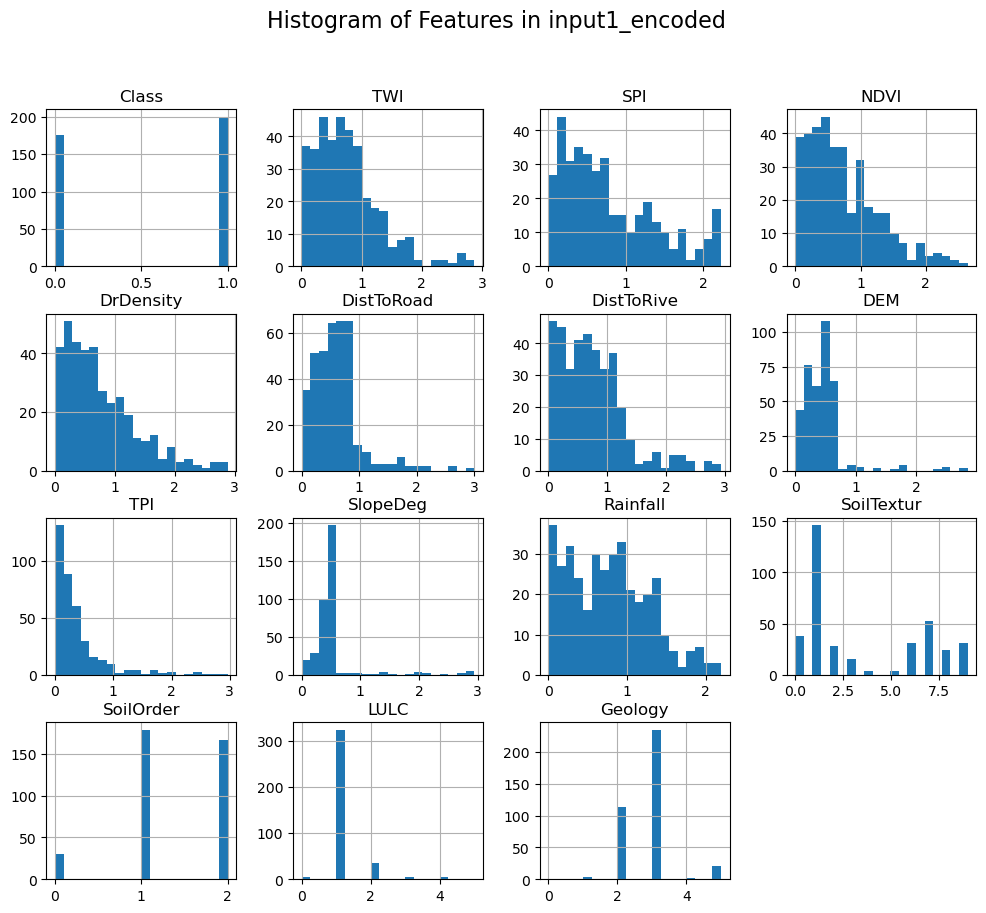

In [34]:
# Plot the histogram of each feature in input1_encoded
input1_encoded.hist(figsize=(12, 10), bins=20)
plt.suptitle("Histogram of Features in input1_encoded", fontsize=16)
plt.show()

#### Feature Engineering (Not used)

In [28]:
# # Select the features for feature engineering
# selected_features = ['TWI', 'SPI', 'NDVI', 'DrDensity', 'DistToRoad', 'DistToRive', 'DEM', 'TPI', 'SlopeDeg', 'Rainfall']

# # Extract the selected features from input1_encoded
# selected_data = input1_encoded[selected_features]

# # Apply feature transformations (e.g., logarithmic, square root, etc.)
# transformed_data = pd.DataFrame()

# # Apply square root transformation to each selected feature
# for feature in selected_data.columns:
#     transformed_data[f'{feature}_sqrt'] = np.sqrt(selected_data[feature]) # square root
#     transformed_data[f'{feature}_log'] = np.log1p(selected_data[feature]) # natural logarithm +1
#     transformed_data[f'{feature}_cbrt'] = np.cbrt(selected_data[feature]) # cube root

# # Concatenate the transformed features with the selected features
# input1_transformed = pd.concat([input1_encoded, transformed_data], axis=1)
# # # Print the transformed data
# # print(input1_transformed.columns)
# # input1_transformed

# ###############LASSO##################
# # Split the data into features (X) and target variable (y)
# X = input1_transformed.drop('Class', axis=1)
# y = input1_transformed['Class']

# # Create a Lasso regression model
# lasso = Lasso(alpha=0.1)

# # Fit the model to the data
# lasso.fit(X, y)

# # Get the coefficients of the model
# coefficients = lasso.coef_

# # Create a DataFrame to store the feature names and corresponding coefficients
# feature_coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})

# # Sort the features by their absolute coefficient values in descending order
# feature_coefficients = feature_coefficients.reindex(
#     feature_coefficients['Coefficient'].abs().sort_values(ascending=False).index
# )

# # Print the feature coefficients
# print(feature_coefficients)


#### VIF and TOL Calculation after Label Encoding

In [35]:
# Calculate VIF and TOL
X = input1_encoded.drop('Class', axis=1)  # Exclude the 'Class' column
# X = engineered_data.drop('Class', axis=1)  # Exclude the 'Class' column

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["TOL"] = 1 / vif["VIF"]

# print VIF and TOL
vif
vif_sorted = vif.sort_values (by='VIF', ascending=True)
vif_sorted

,Feature,VIF,TOL
7,TPI,2.136805,0.467989
10,SoilTextur,2.398856,0.416865
3,DrDensity,2.677745,0.373449
0,TWI,2.693902,0.371209
1,SPI,2.739232,0.365066
5,DistToRive,2.889800,0.346045
4,DistToRoad,3.008071,0.332439
2,NDVI,3.368938,0.296829
9,Rainfall,3.498574,0.285831
6,DEM,5.000447,0.199982


### Correlation

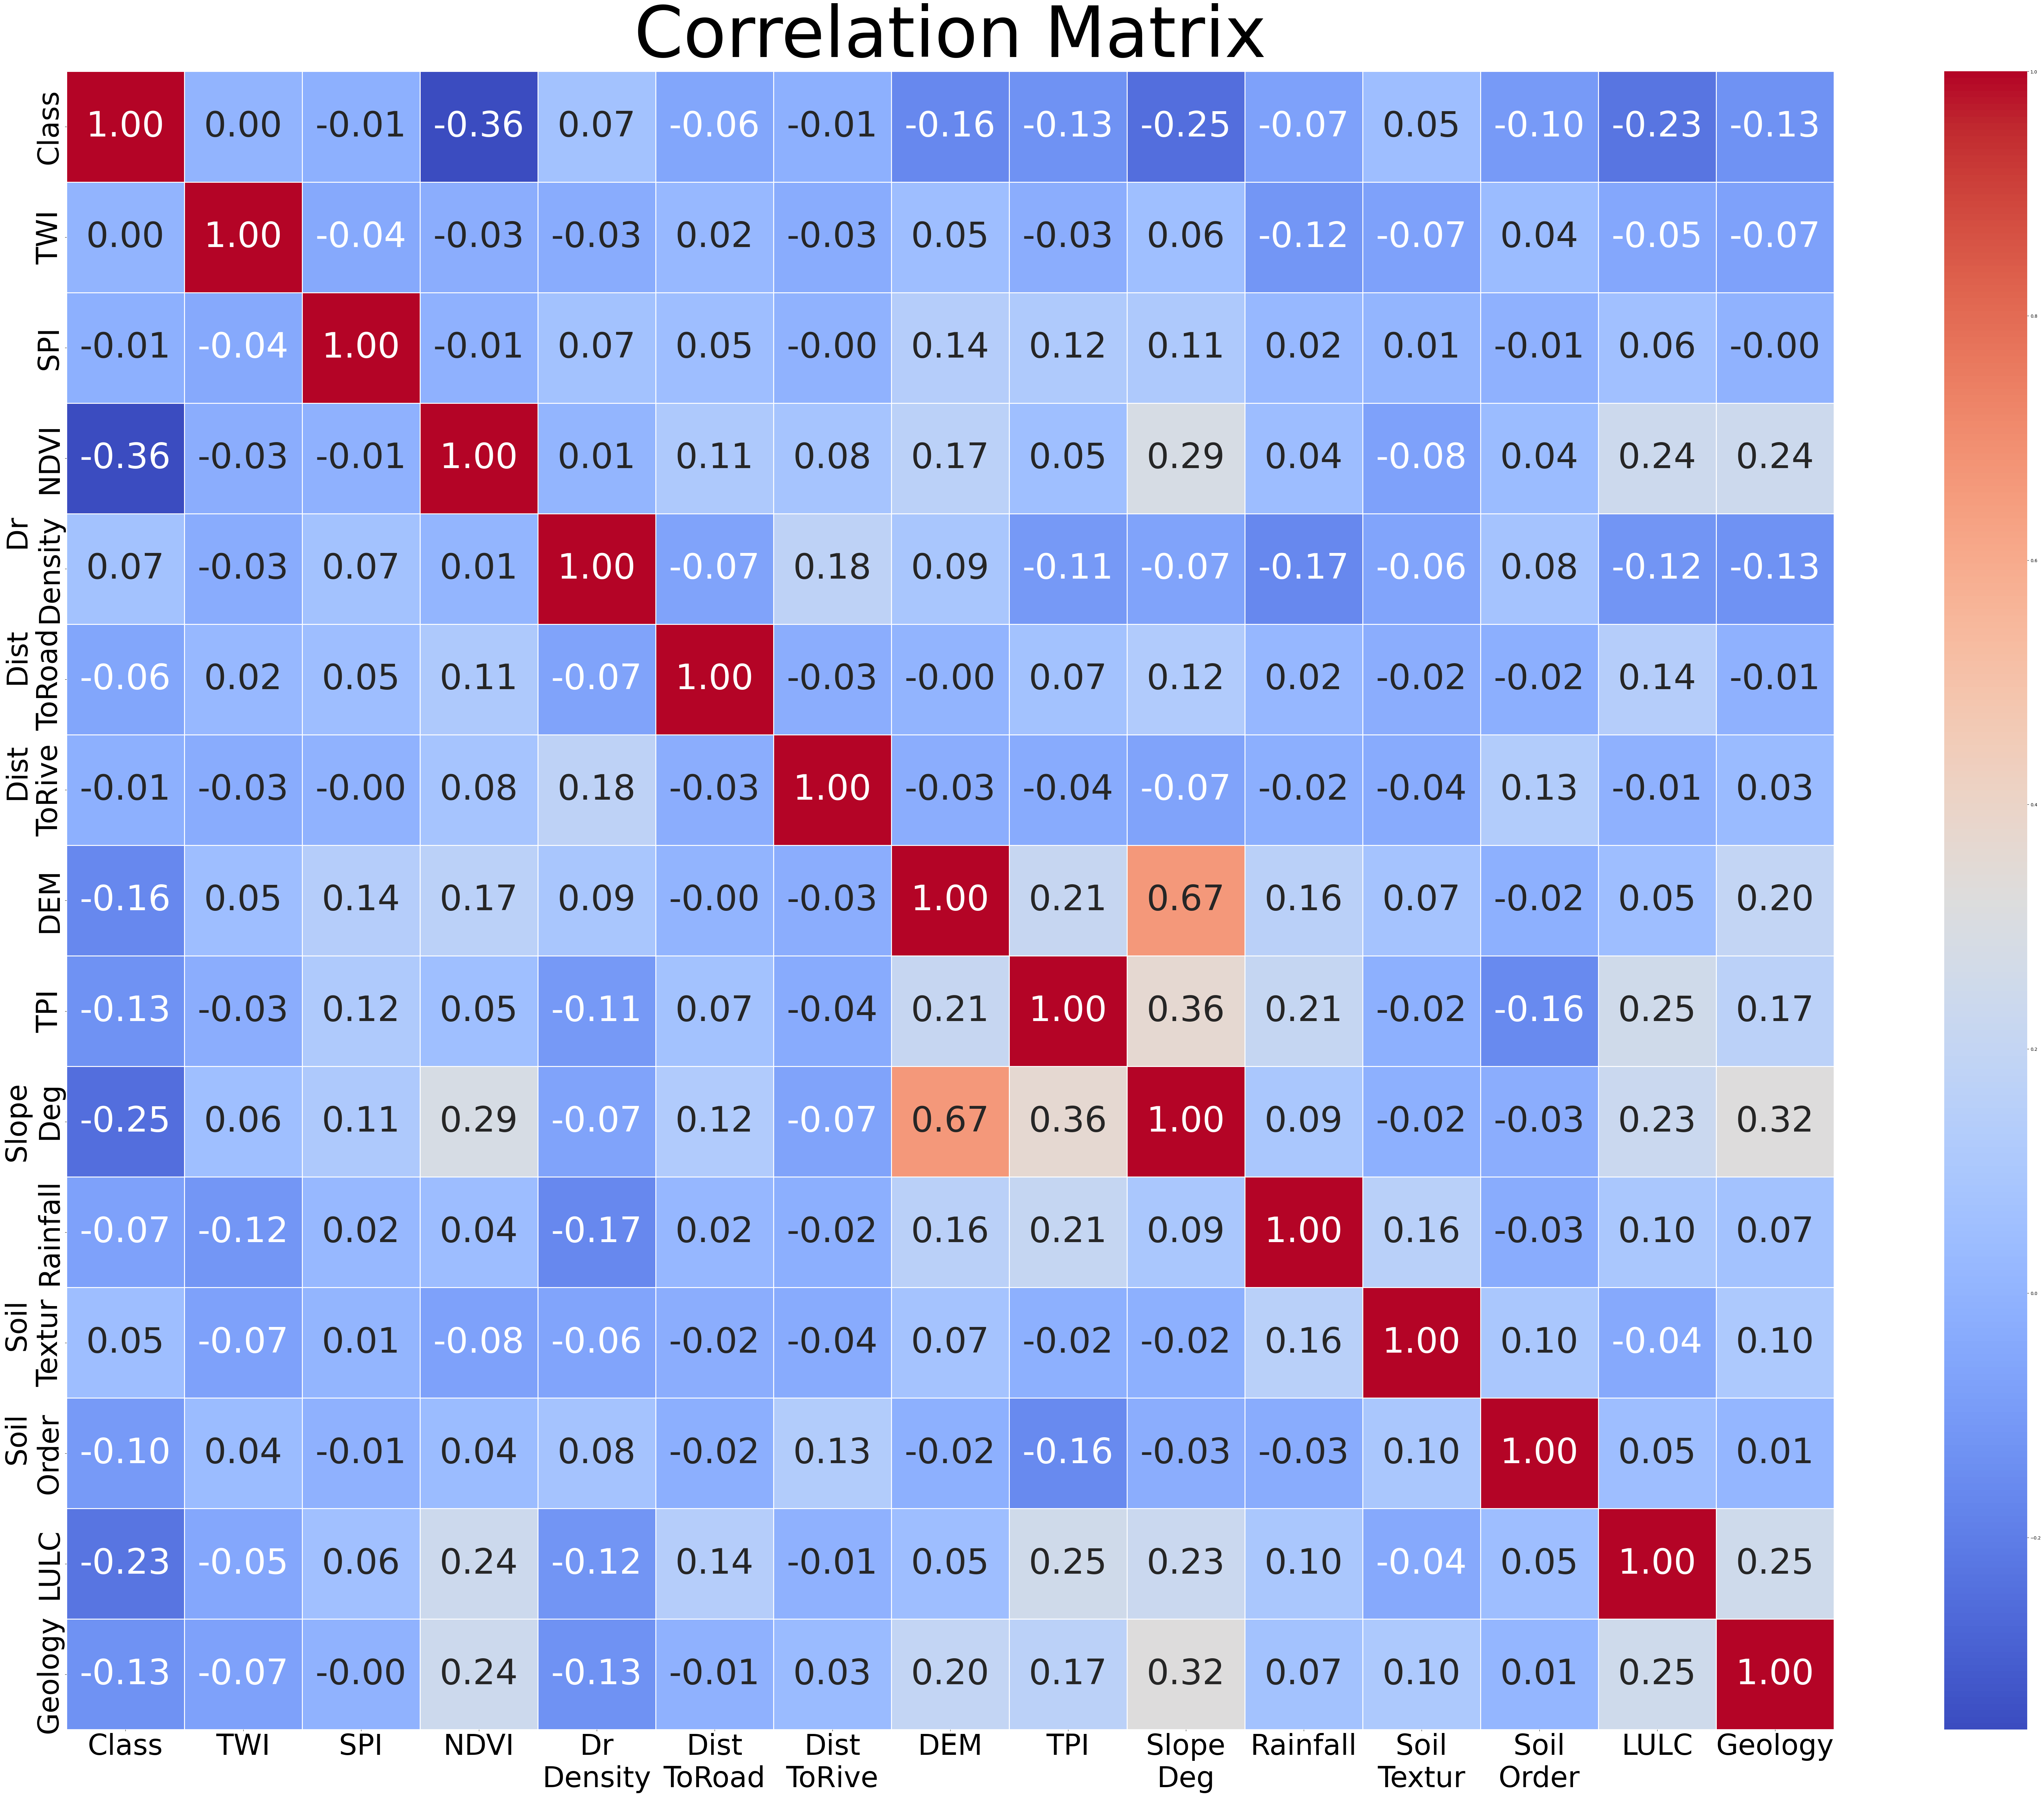

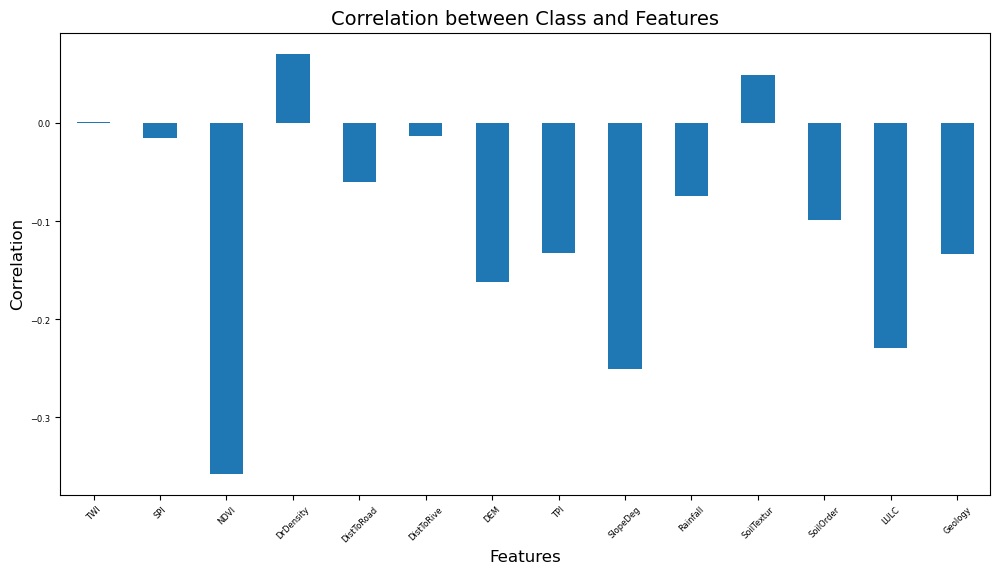

In [36]:
# Calculate the correlation matrix
correlation_matrix = input1_encoded.corr()

# print(correlation_matrix)

# Calculate the correlation between 'Class' and all other features
class_correlation = correlation_matrix['Class'].drop('Class')

# # Plot the correlation matrix
# plt.figure(figsize=(90, 68))
# sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=1,annot_kws={"fontsize": 80})
# plt.title('Correlation Matrix',fontsize= 160)
# plt.xticks(fontsize=60)
# plt.yticks(fontsize=60)
# plt.show()


# Function to insert '\n' after specific keywords
def wrap_label(label):
    if 'Dist' in label:
        return label.replace('Dist', 'Dist\n')
    elif 'Slope' in label:
        return label.replace('Slope', 'Slope\n')
    elif 'Dr' in label:
        return label.replace('Dr', 'Dr\n')    
    elif 'Soil' in label:
        return label.replace('Soil', 'Soil\n')
    return label

# Plot the correlation matrix with updated settings
plt.figure(figsize=(90, 68))
heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=1,
    annot_kws={"fontsize": 80}
)

# Set x and y axis labels with word wrapping for specific keywords
heatmap.set_xticklabels(
    [wrap_label(label.get_text()) for label in heatmap.get_xticklabels()],
    fontsize=65
)
heatmap.set_yticklabels(
    [wrap_label(label.get_text()) for label in heatmap.get_yticklabels()],
    fontsize=65
)

plt.title('Correlation Matrix', fontsize=160)
# Save the plot as a JPEG file
plt.savefig('correlation_matrix.jpeg', format='jpeg', dpi=400)
plt.show()


# Plot the correlation between 'Class' and all other features
plt.figure(figsize=(12, 6))
class_correlation.plot(kind='bar')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.title('Correlation between Class and Features', fontsize=14)
plt.xticks(rotation=45, fontsize=6)
plt.yticks(fontsize=6)
plt.show()


### Feature Importance

#### Feature Importance using RandomForestClassifier (Not necessary/Just for comparision with RFRegressor)

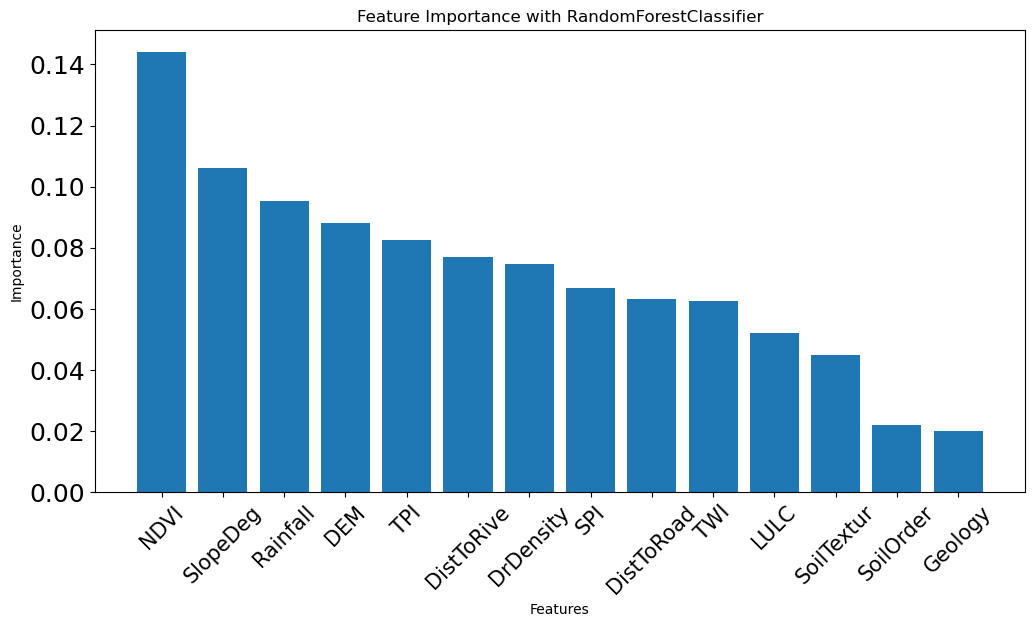

       Feature  Importance
2         NDVI    0.144007
8     SlopeDeg    0.106018
9     Rainfall    0.095315
6          DEM    0.088214
7          TPI    0.082598
5   DistToRive    0.077004
3    DrDensity    0.074814
1          SPI    0.066985
4   DistToRoad    0.063146
0          TWI    0.062673
12        LULC    0.052108
10  SoilTextur    0.044976
11   SoilOrder    0.022034
13     Geology    0.020108


In [71]:
# Split the data into features (X) and target variable (y)
X = input1_encoded.drop('Class', axis=1)
y = input1_encoded['Class']

# Create a Random Forest classifier
rf = RandomForestClassifier()

# Fit the classifier to the data
rf.fit(X, y)

# Get the feature importances
importances = rf.feature_importances_

# Create a DataFrame to store the feature names and importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Sort the features by importance in descending order
feature_importances = feature_importances.sort_values('Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 6))
plt.bar(feature_importances['Feature'], feature_importances['Importance'])
plt.xlabel('Features', fontsize=10)
plt.ylabel('Importance', fontsize=10)
plt.title('Feature Importance with RandomForestClassifier', fontsize=12)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=18)
plt.show()

# Print the feature importances
print(feature_importances)

#### Feature Importance using RandomForestRegressor

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


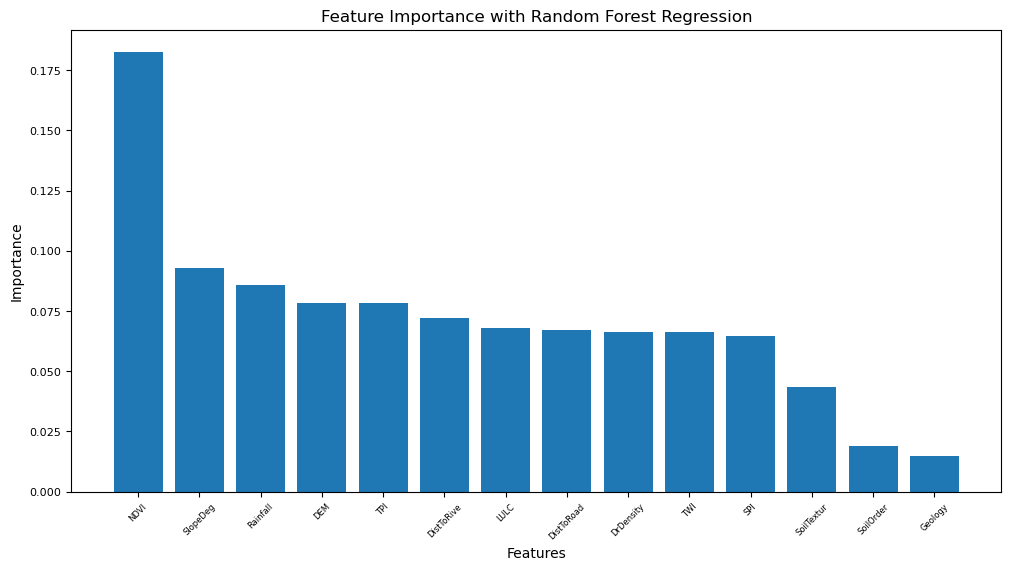

       Feature  Importance
2         NDVI    0.182678
8     SlopeDeg    0.092951
9     Rainfall    0.085814
6          DEM    0.078508
7          TPI    0.078154
5   DistToRive    0.072236
12        LULC    0.068126
4   DistToRoad    0.067003
3    DrDensity    0.066438
0          TWI    0.066369
1          SPI    0.064549
10  SoilTextur    0.043551
11   SoilOrder    0.018921
13     Geology    0.014701


In [33]:
# Create a Random Forest regression model
rf = RandomForestRegressor()
print(rf.get_params())

# Fit the model to the data
rf.fit(X, y)

# Get the feature importances
importances = rf.feature_importances_

# Create a DataFrame to store the feature names and importances
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Sort the features by importance in descending order
feature_importances = feature_importances.sort_values('Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 6))
plt.bar(feature_importances['Feature'], feature_importances['Importance'])
plt.xlabel('Features', fontsize=10)
plt.ylabel('Importance', fontsize=10)
plt.title('Feature Importance with Random Forest Regression', fontsize=12)
plt.xticks(rotation=45, fontsize=6)
plt.yticks(fontsize=8)
plt.show()

# Print the feature importances
print(feature_importances)

#### Feature Selection using RFE(Recursive Feature Elimination)

In [34]:
# Create the RFE object and specify the number of features to select
rfe = RFE(estimator=rf, n_features_to_select=13) # 19 and 13 was found to be the optimum number with no high VIF values >10 for OneHotEncoding & Label resp. 

# Fit the RFE to the data
rfe.fit(X, y)

# Get the selected features
selected_features = X.columns[rfe.support_]

# Get the feature rankings
feature_rankings = rfe.ranking_

# Create a DataFrame to store the feature names and rankings
feature_rankings_df = pd.DataFrame({'Feature': X.columns, 'Ranking': feature_rankings})

# Sort the features by ranking in ascending order
feature_rankings_df = feature_rankings_df.sort_values('Ranking')

# # Plot the feature rankings
# plt.figure(figsize=(10, 4))
# plt.bar(feature_rankings_df['Feature'], feature_rankings_df['Ranking'])
# plt.xlabel('Features', fontsize=12)
# plt.ylabel('Ranking', fontsize=12)
# plt.title('Feature Rankings with RSE', fontsize=12)
# plt.xticks(rotation=45, fontsize=6)
# plt.yticks(fontsize=6)
# plt.show()

# Print the selected features and their rankings
print("Selected Features:")
print(selected_features)
print("\nFeature Rankings:")
print(feature_rankings_df)

Selected Features:
Index(['TWI', 'SPI', 'NDVI', 'DrDensity', 'DistToRoad', 'DistToRive', 'DEM',
       'TPI', 'SlopeDeg', 'Rainfall', 'SoilTextur', 'SoilOrder', 'LULC'],
      dtype='object')

Feature Rankings:
       Feature  Ranking
0          TWI        1
1          SPI        1
2         NDVI        1
3    DrDensity        1
4   DistToRoad        1
5   DistToRive        1
6          DEM        1
7          TPI        1
8     SlopeDeg        1
9     Rainfall        1
10  SoilTextur        1
11   SoilOrder        1
12        LULC        1
13     Geology        2


## Models


### Random Forest

#### Modeling using all Features and Metrics

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 3, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}

The thresholds for Train data are: [1.98 0.98 0.97 0.96 0.95 0.94 0.93 0.92 0.91 0.9  0.89 0.88 0.87 0.86
 0.84 0.83 0.82 0.81 0.8  0.79 0.78 0.77 0.76 0.75 0.74 0.73 0.67 0.35
 0.33 0.32 0.3  0.29 0.28 0.27 0.26 0.24 0.23 0.22 0.2  0.19 0.18 0.16
 0.15 0.14 0.13 0.12 0.11 0.1  0.09 0.08 0.07 0.06 0.04 0.03 0.02 0.01]

The metrics for the TRAIN data are:

Root Mean Squared Error (RMSE): 0.16540959262791663
Mean Squared Error: 0.027360333333333334
Median Absolute Error (MedAE): 0.13
Mean Absolute Error (MAE): 0.14743333333333333
R^2 Score: 0.8899669332856696
Explained Variance Score: 0.8901474641404888
AUC: 1.0

The t

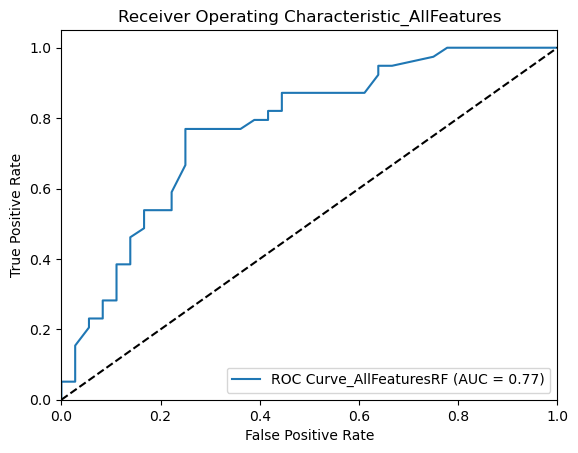

In [35]:
# Split the data into features (X) and target variable (y)
X = input1_encoded.drop('Class', axis=1)
y = input1_encoded['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest Regression model
rf = RandomForestRegressor(bootstrap= True,max_features=3) 
print(rf.get_params())

# Train the model
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)


# Calculate metrics for the training data
y_train_pred = rf.predict(X_train)

rmse_train_AllFeatRF = np.sqrt(mean_squared_error(y_train, y_train_pred))
mse_train_AllFeatRF = mean_squared_error(y_train, y_train_pred)
mae_train_AllFeatRF = mean_absolute_error(y_train, y_train_pred)
r2_train_AllFeatRF = r2_score(y_train, y_train_pred)
evs_train_AllFeatRF = explained_variance_score(y_train, y_train_pred)
medae_train_AllFeatRF = median_absolute_error(y_train, y_train_pred)
auc_train_AllFeatRF = roc_auc_score(y_train, y_train_pred)
fpr_train_AllFeatRF, tpr_train_AllFeatRF, thresholds_train_AllFeatRF = roc_curve(y_train, y_train_pred)

print('\nThe thresholds for Train data are:',thresholds_train_AllFeatRF)

# Print the metrics for training data
print('\nThe metrics for the TRAIN data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_train_AllFeatRF)
print("Mean Squared Error:", mse_train_AllFeatRF)
print("Median Absolute Error (MedAE):", medae_train_AllFeatRF)
print("Mean Absolute Error (MAE):", mae_train_AllFeatRF)
print("R^2 Score:", r2_train_AllFeatRF)
print("Explained Variance Score:", evs_train_AllFeatRF)
print("AUC:", auc_train_AllFeatRF)

# # Plot ROC Curve for training data
# plt.figure()
# plt.plot(fpr_train, tpr_train, label='ROC Curve_Train (AUC = %0.2f)' % auc_train)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic_Train')
# plt.legend(loc='lower right')
# plt.show()

# Calculate metrics or TEST data
rmse_AllFeatRF = np.sqrt(mean_squared_error(y_test, y_pred))
# cm = confusion_matrix(y_test, y_pred)
# kappa = cohen_kappa_score(y_test, y_pred)
mse_AllFeatRF = mean_squared_error(y_test, y_pred)
mae_AllFeatRF = mean_absolute_error(y_test, y_pred)
r2_AllFeatRF = r2_score(y_test, y_pred)
evs_AllFeatRF = explained_variance_score(y_test, y_pred)
medae_AllFeatRF = median_absolute_error(y_test, y_pred)
auc_AllFeatRF = roc_auc_score(y_test, y_pred)
fpr_AllFeatRF, tpr_AllFeatRF, thresholds_AllFeatRF = roc_curve(y_test, y_pred)

print('\nThe thresholds are:',thresholds_AllFeatRF)

# Print the metrics
print('\nThe metrics for the TEST data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_AllFeatRF)
print("Mean Squared Error:", mse_AllFeatRF)
print("Median Absolute Error (MedAE):", medae_AllFeatRF)
print("Mean Absolute Error (MAE):", mae_AllFeatRF)
print("R^2 Score:", r2_AllFeatRF)
print("Explained Variance Score:", evs_AllFeatRF)
# print("Confusion Matrix:\n", cm)
# print("Cohen's Kappa:", kappa)
print("AUC:", auc_AllFeatRF)

# Plot ROC Curve
plt.figure()
plt.plot(fpr_AllFeatRF, tpr_AllFeatRF, label='ROC Curve_AllFeaturesRF (AUC = %0.2f)' % auc_AllFeatRF)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic_AllFeatures')
plt.legend(loc='lower right')
plt.show()

In [36]:
# # Save the trained model to a file
# joblib.dump(rf, 'RF_AllFeatures.joblib')

#### Modeling using only Selected Features from RFE and METRICS

Model Parameters: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}

The thresholds for Train data are: [1.99 0.99 0.98 0.97 0.96 0.94 0.92 0.91 0.9  0.89 0.88 0.87 0.86 0.85
 0.84 0.82 0.81 0.8  0.79 0.78 0.77 0.76 0.75 0.74 0.72 0.71 0.62 0.34
 0.3  0.29 0.28 0.27 0.25 0.24 0.23 0.22 0.21 0.2  0.18 0.17 0.16 0.15
 0.13 0.12 0.11 0.1  0.09 0.08 0.07 0.06 0.05 0.04 0.03 0.02 0.  ]

The metrics for the TRAIN data are:

Root Mean Squared Error (RMSE): 0.16781338842098784
Mean Squared Error: 0.02816133333333333
Median Absolute Error (MedAE): 0.13
Mean Absolute Error (MAE): 0.145
R^2 Score: 0.8867456097234014
Explained Variance Score: 0.8867802135931007
AUC: 1.0

The T

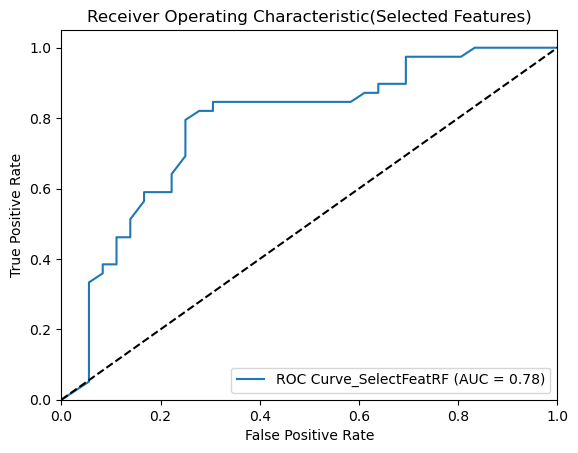

In [47]:
# Split the data into features (X) and target variable (y)
X = input1_encoded[selected_features]
y = input1_encoded['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest Regression model
rf = RandomForestRegressor()

# Print the model parameters
print("Model Parameters:", rf.get_params())

# Train the model
rf.fit(X_train, y_train)

# Calculate metrics for the training data
y_train_pred = rf.predict(X_train)

rmse_train_SelectFeatRF = np.sqrt(mean_squared_error(y_train, y_train_pred))
mse_train_SelectFeatRF = mean_squared_error(y_train, y_train_pred)
mae_train_SelectFeatRF = mean_absolute_error(y_train, y_train_pred)
r2_train_SelectFeatRF = r2_score(y_train, y_train_pred)
evs_train_SelectFeatRF = explained_variance_score(y_train, y_train_pred)
medae_train_SelectFeatRF = median_absolute_error(y_train, y_train_pred)
auc_train_SelectFeatRF = roc_auc_score(y_train, y_train_pred)
fpr_train_SelectFeatRF, tpr_train_SelectFeatRF, thresholds_train_SelectFeatRF = roc_curve(y_train, y_train_pred)

print('\nThe thresholds for Train data are:',thresholds_train_SelectFeatRF)

# Print the metrics for training data
print('\nThe metrics for the TRAIN data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_train_SelectFeatRF)
print("Mean Squared Error:", mse_train_SelectFeatRF)
print("Median Absolute Error (MedAE):", medae_train_SelectFeatRF)
print("Mean Absolute Error (MAE):", mae_train_SelectFeatRF)
print("R^2 Score:", r2_train_SelectFeatRF)
print("Explained Variance Score:", evs_train_SelectFeatRF)
print("AUC:", auc_train_SelectFeatRF)

# # Plot ROC Curve for training data
# plt.figure()
# plt.plot(fpr_train, tpr_train, label='ROC Curve_Train (AUC = %0.2f)' % auc_train)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic_Train')
# plt.legend(loc='lower right')
# plt.show()

# Predict on the test set
y_pred = rf.predict(X_test)

# Calculate metrics for TEST data
rmse_SelectFeatRF = np.sqrt(mean_squared_error(y_test, y_pred))
# cm = confusion_matrix(y_test, y_pred)
# kappa = cohen_kappa_score(y_test, y_pred)
mse_SelectFeatRF = mean_squared_error(y_test, y_pred)
mae_SelectFeatRF = mean_absolute_error(y_test, y_pred)
r2_SelectFeatRF = r2_score(y_test, y_pred)
evs_SelectFeatRF = explained_variance_score(y_test, y_pred)
medae_SelectFeatRF = median_absolute_error(y_test, y_pred)
auc_SelectFeatRF = roc_auc_score(y_test, y_pred)
fprSelectFeatRF, tprSelectFeatRF, thresholdsSelectFeatRF = roc_curve(y_test, y_pred)

print ('\nThe Thresholds are:', thresholdsSelectFeatRF)

# Print the metrics
print('\nThe metrics for the TEST data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_SelectFeatRF)
print("Mean Squared Error:", mse_SelectFeatRF)
print("Median Absolute Error (MedAE):", medae_SelectFeatRF)
print("Mean Absolute Error (MAE):", mae_SelectFeatRF)
print("R^2 Score:", r2_SelectFeatRF)
print("Explained Variance Score:", evs_SelectFeatRF)
print("AUC:", auc_SelectFeatRF)

# Plot ROC Curve
plt.figure()
plt.plot(fprSelectFeatRF, tprSelectFeatRF, label='ROC Curve_SelectFeatRF (AUC = %0.2f)' % auc_SelectFeatRF)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic(Selected Features)')
plt.legend(loc='lower right')
plt.show()

In [48]:
# # Save the trained model to a file
# joblib.dump(rf, 'RF_RFE_SelectedFeatures.joblib')

#### Modeling using GridSearchCrossValidation method

The best estimators are:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 150, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Iteration No: 0
Current AUC: 0.786
The best estimators are:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'log2', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 150, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Iteration No: 1
Current AUC: 0.781
The best estimators are:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_

The best estimators are:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'log2', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 150, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Iteration No: 19
Current AUC: 0.798
The best estimators are:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 80, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Iteration No: 20
Current AUC: 0.801
The best estimators are:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max

The best estimators are:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 150, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Iteration No: 38
Current AUC: 0.783
The best estimators are:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 80, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Iteration No: 39
Current AUC: 0.765
The best estimators are:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max

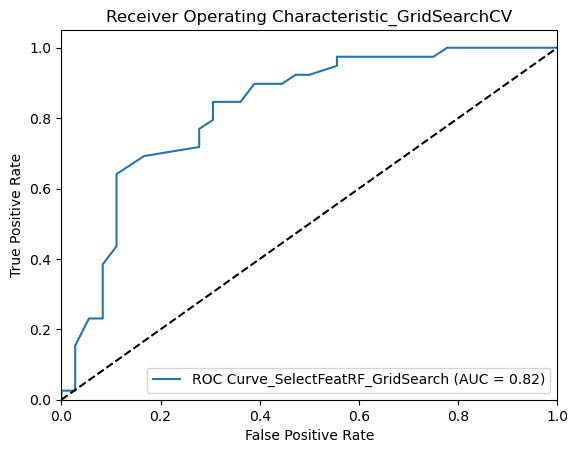

In [60]:
# Define the target AUC value
target_auc = 0.815 #0.815 for threshold 3, 0.765 for threshold 4

# Initialize variables
iterations = 0
auc = 0

while iterations < 480 and auc < target_auc:
    # Split the data into features (X) and target variable (y)
    X = input1_encoded[selected_features]
    y = input1_encoded['Class']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Define the parameter grid for Grid Search
    param_grid = {
        'n_estimators': [100, 80, 90, 150],
        'max_depth': [None],
        'min_samples_split': [2],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt','log2',6]
    }

    # Create a Random Forest Regression model
    rf = RandomForestRegressor()

    # Create the Grid Search Cross Validation object
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)

    # Train the model using Grid Search Cross Validation
    grid_search.fit(X_train, y_train)

    # Get the best model
    best_model = grid_search.best_estimator_
    print('The best estimators are:\n', best_model.get_params())

    # Predict on the test set using the best model
    y_pred = best_model.predict(X_test)

    # Calculate AUC
    auc_SelectFeatRF_GridSearchCV = roc_auc_score(y_test, y_pred)
    print("Iteration No:", iterations)
    print("Current AUC: %.3f" % auc_SelectFeatRF_GridSearchCV)
    
    # Check if the desired AUC is reached
    if auc_SelectFeatRF_GridSearchCV > target_auc:
        print("Desired AUC reached!")
        break

    # Increment the counter
    iterations += 1

# Print the final number of iterations
print("Total iterations:", iterations)
    

# Calculate metrics for the training data
y_train_pred = best_model.predict(X_train)

rmse_train_SelectFeatRF_GridSearchCV = np.sqrt(mean_squared_error(y_train, y_train_pred))
mse_train_SelectFeatRF_GridSearchCV = mean_squared_error(y_train, y_train_pred)
mae_train_SelectFeatRF_GridSearchCV = mean_absolute_error(y_train, y_train_pred)
r2_train_SelectFeatRF_GridSearchCV = r2_score(y_train, y_train_pred)
evs_train_SelectFeatRF_GridSearchCV = explained_variance_score(y_train, y_train_pred)
medae_train_SelectFeatRF_GridSearchCV = median_absolute_error(y_train, y_train_pred)
auc_train_SelectFeatRF_GridSearchCV = roc_auc_score(y_train, y_train_pred)
fpr_train_SelectFeatRF_GridSearchCV, tpr_train_SelectFeatRF_GridSearchCV, thresholds_train_SelectFeatRF_GridSearchCV = roc_curve(y_train, y_train_pred)

print('\nThe thresholds for Train data are:',thresholds_train_SelectFeatRF_GridSearchCV)

# Print the metrics for training data
print('\nThe metrics for the TRAIN data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_train_SelectFeatRF_GridSearchCV)
print("Mean Squared Error:", mse_train_SelectFeatRF_GridSearchCV)
print("Median Absolute Error (MedAE):", medae_train_SelectFeatRF_GridSearchCV)
print("Mean Absolute Error (MAE):", mae_train_SelectFeatRF_GridSearchCV)
print("R^2 Score:", r2_train_SelectFeatRF_GridSearchCV)
print("Explained Variance Score:", evs_train_SelectFeatRF_GridSearchCV)
print("AUC:", auc_train_SelectFeatRF_GridSearchCV)

# # Plot ROC Curve for training data
# plt.figure()
# plt.plot(fpr_train, tpr_train, label='ROC Curve_Train (AUC = %0.2f)' % auc_train)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic_Train')
# plt.legend(loc='lower right')
# plt.show()
    
# Calculate metrics for TEST data
rmse_SelectFeatRF_GridSearchCV = np.sqrt(mean_squared_error(y_test, y_pred))
mse_SelectFeatRF_GridSearchCV = mean_squared_error(y_test, y_pred)
mae_SelectFeatRF_GridSearchCV = mean_absolute_error(y_test, y_pred)
r2_SelectFeatRF_GridSearchCV = r2_score(y_test, y_pred)
evs_SelectFeatRF_GridSearchCV = explained_variance_score(y_test, y_pred)
medae_SelectFeatRF_GridSearchCV = median_absolute_error(y_test, y_pred)
fpr_SelectFeatRF_GridSearchCV, tpr_SelectFeatRF_GridSearchCV, thresholds_SelectFeatRF_GridSearchCV = roc_curve(y_test, y_pred)

# Print the metrics
print('\nThe metrics for the TEST data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_SelectFeatRF_GridSearchCV)
print("Mean Squared Error:", mse_SelectFeatRF_GridSearchCV)
print("Median Absolute Error (MedAE):", medae_SelectFeatRF_GridSearchCV)
print("Mean Absolute Error (MAE):", mae_SelectFeatRF_GridSearchCV)
print("R^2 Score:", r2_SelectFeatRF_GridSearchCV)
print("Explained Variance Score:", evs_SelectFeatRF_GridSearchCV)
print("AUC:", auc_SelectFeatRF_GridSearchCV)

# Plot ROC Curve
plt.figure()
plt.plot(fpr_SelectFeatRF_GridSearchCV, tpr_SelectFeatRF_GridSearchCV, label='ROC Curve_SelectFeatRF_GridSearch (AUC = %0.2f)' % auc_SelectFeatRF_GridSearchCV)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic_GridSearchCV')
plt.legend(loc='lower right')
plt.show()

In [50]:
# # Save the best model
# joblib.dump(best_model, 'RF_RFE_SelectedFeatures_GridSearchCV.joblib')

### XGboost

#### Modeling using only Selected Features from RFE and METRICS

Model Parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'gpu_id': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'n_estimators': 100, 'n_jobs': None, 'num_parallel_tree': None, 'predictor': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


The thresholds for Train data are: [ 2.0019231e+00  1.0019232e+00  9.9743396e-01 -1.3

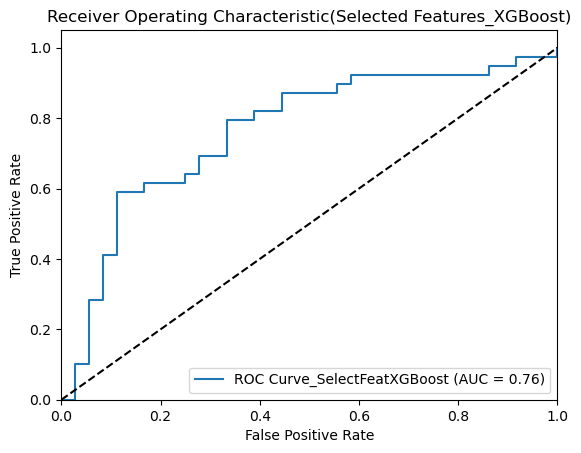

In [51]:
# Split the data into features (X) and target variable (y)
X = input1_encoded[selected_features]
y = input1_encoded['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an XGBoost regression model
xgb_model = xgb.XGBRegressor()

# Print the model parameters
print("Model Parameters:", xgb_model.get_params())
print()

# Train the model
xgb_model.fit(X_train, y_train)

# Calculate metrics for the training data
y_train_pred = xgb_model.predict(X_train)

rmse_train_SelectFeatXGBoost = np.sqrt(mean_squared_error(y_train, y_train_pred))
mse_train_SelectFeatXGBoost = mean_squared_error(y_train, y_train_pred)
mae_train_SelectFeatXGBoost = mean_absolute_error(y_train, y_train_pred)
r2_train_SelectFeatXGBoost = r2_score(y_train, y_train_pred)
evs_train_SelectFeatXGBoost = explained_variance_score(y_train, y_train_pred)
medae_train_SelectFeatXGBoost = median_absolute_error(y_train, y_train_pred)
auc_train_SelectFeatXGBoost = roc_auc_score(y_train, y_train_pred)
fpr_train_SelectFeatXGBoost, tpr_train_SelectFeatXGBoost, thresholds_train_SelectFeatXGBoost = roc_curve(y_train, y_train_pred)

print('\nThe thresholds for Train data are:',thresholds_train_SelectFeatXGBoost)

# Print the metrics for training data
print('\nThe metrics for the TRAIN data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_train_SelectFeatXGBoost)
print("Mean Squared Error:", mse_train_SelectFeatXGBoost)
print("Median Absolute Error (MedAE):", medae_train_SelectFeatXGBoost)
print("Mean Absolute Error (MAE):", mae_train_SelectFeatXGBoost)
print("R^2 Score:", r2_train_SelectFeatXGBoost)
print("Explained Variance Score:", evs_train_SelectFeatXGBoost)
print("AUC:", auc_train_SelectFeatXGBoost)

# # Plot ROC Curve for training data
# plt.figure()
# plt.plot(fpr_train, tpr_train, label='ROC Curve_Train (AUC = %0.2f)' % auc_train)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic_Train')
# plt.legend(loc='lower right')
# plt.show()

# Predict on the test set
y_pred = xgb_model.predict(X_test)

# Calculate metrics for the TEST data
rmse_SelectFeatXGBoost = np.sqrt(mean_squared_error(y_test, y_pred))
mse_SelectFeatXGBoost = mean_squared_error(y_test, y_pred)
mae_SelectFeatXGBoost = mean_absolute_error(y_test, y_pred)
r2_SelectFeatXGBoost = r2_score(y_test, y_pred)
evs_SelectFeatXGBoost = explained_variance_score(y_test, y_pred)
medae_SelectFeatXGBoost = median_absolute_error(y_test, y_pred)
fpr_SelectFeatXGBoost, tpr_SelectFeatXGBoost, thresholds_SelectFeatXGBoost = roc_curve(y_test, y_pred)
auc_SelectFeatXGBoost = roc_auc_score(y_test, y_pred)

# # Calculate VIF and TOL
# vif_SelectFeatXGBoost = pd.DataFrame()
# vif_SelectFeatXGBoost["Feature"] = X_train.columns
# vif_SelectFeatXGBoost["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
# vif_SelectFeatXGBoost["TOL"] = 1 / vif_SelectFeatXGBoost["VIF"]

# Print the metrics, VIF, and TOL
print('\nThe metrics for the TEST data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_SelectFeatXGBoost)
print("Mean Squared Error:", mse_SelectFeatXGBoost)
print("Median Absolute Error (MedAE):", medae_SelectFeatXGBoost)
print("Mean Absolute Error (MAE):", mae_SelectFeatXGBoost)
print("R^2 Score:", r2_SelectFeatXGBoost)
print("Explained Variance Score:", evs_SelectFeatXGBoost)
print("AUC:", auc_SelectFeatXGBoost)
# print("\nVariance Inflation Factor (VIF) and Tolerance (TOL):")
# print(vif_SelectFeatXGBoost)

# Plot ROC Curve
plt.figure()
plt.plot(fpr_SelectFeatXGBoost, tpr_SelectFeatXGBoost, label='ROC Curve_SelectFeatXGBoost (AUC = %0.2f)' % auc_SelectFeatXGBoost)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic(Selected Features_XGBoost)')
plt.legend(loc='lower right')
plt.show()

In [52]:
# Save the trained model
joblib.dump(xgb_model, 'XGBoost_RFE_SelectedFeatures_try.joblib')

['XGBoost_RFE_SelectedFeatures_try.joblib']

#### Modeling using GridSearchCrossValidation method


The thresholds for Train data are: [ 2.0285337  1.0285337  0.9267773 -0.0235114]

The metrics for the TRAIN data are:

Root Mean Squared Error (RMSE): 0.02055815150163948
Mean Squared Error: 0.00042263759316436166
Median Absolute Error (MedAE): 0.00895367981866002
Mean Absolute Error (MAE): 0.014555864691901661
R^2 Score: 0.9983003090672151
Explained Variance Score: 0.9983005023270444
AUC: 1.0

The metrics for the TEST data are:

Root Mean Squared Error (RMSE): 0.460879187872162
Mean Squared Error: 0.2124096258137036
Median Absolute Error (MedAE): 0.27387142181396484
Mean Absolute Error (MAE): 0.3606058022715539
R^2 Score: 0.14899989657971302
Explained Variance Score: 0.15657601523773113
AUC:  0.7656695156695157
Best Parameters {'learning_rate': None, 'max_depth': None, 'n_estimators': 40}


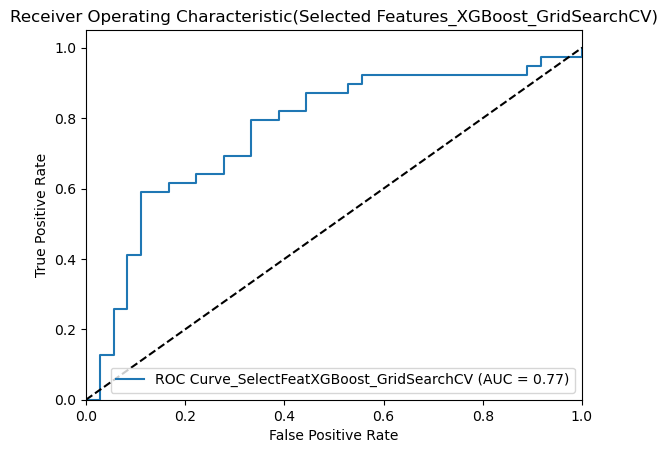

In [53]:
# Split the data into features (X) and target variable (y)
X = input1_encoded[selected_features]
y = input1_encoded['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [100, 50, 40, 30, 60, 70, 80, 90, 150],
    'max_depth': [None, 50, 100],
    'learning_rate': [None, 0.00001 , 0.3]
}

# Create an XGBoost regression model
xgb_model = xgb.XGBRegressor()

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5)

# Perform grid search on the training data
grid_search.fit(X_train, y_train)

# Get the best estimator and predicted values
best_estimator = grid_search.best_estimator_
y_pred = best_estimator.predict(X_test)

# Calculate metrics for the training data
y_train_pred = best_estimator.predict(X_train)

rmse_train_SelectFeatXGBoost_GridSearch = np.sqrt(mean_squared_error(y_train, y_train_pred))
mse_train_SelectFeatXGBoost_GridSearch = mean_squared_error(y_train, y_train_pred)
mae_train_SelectFeatXGBoost_GridSearch = mean_absolute_error(y_train, y_train_pred)
r2_train_SelectFeatXGBoost_GridSearch = r2_score(y_train, y_train_pred)
evs_train_SelectFeatXGBoost_GridSearch = explained_variance_score(y_train, y_train_pred)
medae_train_SelectFeatXGBoost_GridSearch = median_absolute_error(y_train, y_train_pred)
auc_train_SelectFeatXGBoost_GridSearch = roc_auc_score(y_train, y_train_pred)
fpr_train_SelectFeatXGBoost_GridSearch, tpr_train_SelectFeatXGBoost_GridSearch, thresholds_train_SelectFeatXGBoost_GridSearch = roc_curve(y_train, y_train_pred)

print('\nThe thresholds for Train data are:',thresholds_train_SelectFeatXGBoost_GridSearch)

# Print the metrics for training data
print('\nThe metrics for the TRAIN data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_train_SelectFeatXGBoost_GridSearch)
print("Mean Squared Error:", mse_train_SelectFeatXGBoost_GridSearch)
print("Median Absolute Error (MedAE):", medae_train_SelectFeatXGBoost_GridSearch)
print("Mean Absolute Error (MAE):", mae_train_SelectFeatXGBoost_GridSearch)
print("R^2 Score:", r2_train_SelectFeatXGBoost_GridSearch)
print("Explained Variance Score:", evs_train_SelectFeatXGBoost_GridSearch)
print("AUC:", auc_train_SelectFeatXGBoost_GridSearch)

# # Plot ROC Curve for training data
# plt.figure()
# plt.plot(fpr_train_SelectFeatXGBoost_GridSearch, tpr_train_SelectFeatXGBoost_GridSearch, label='ROC Curve_Train (AUC = %0.2f)' % auc_train_SelectFeatXGBoost_GridSearch)
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic_Train')
# plt.legend(loc='lower right')
# plt.show()

# Calculate metrics of TEST data
rmse_SelectFeatXGBoost_GridSearch = np.sqrt(mean_squared_error(y_test, y_pred))
mse_SelectFeatXGBoost_GridSearch = mean_squared_error(y_test, y_pred)
mae_SelectFeatXGBoost_GridSearch = mean_absolute_error(y_test, y_pred)
r2_SelectFeatXGBoost_GridSearch = r2_score(y_test, y_pred)
evs_SelectFeatXGBoost_GridSearch = explained_variance_score(y_test, y_pred)
medae_SelectFeatXGBoost_GridSearch = median_absolute_error(y_test, y_pred)
fpr_SelectFeatXGBoost_GridSearch, tpr_SelectFeatXGBoost_GridSearch, thresholds_SelectFeatXGBoost_GridSearch = roc_curve(y_test, y_pred)
auc_SelectFeatXGBoost_GridSearch = roc_auc_score(y_test, y_pred)

# # Calculate VIF
# vif_SelectFeatXGBoost_GridSearch = pd.DataFrame()
# vif_SelectFeatXGBoost_GridSearch["Feature"] = X_train.columns
# vif_SelectFeatXGBoost_GridSearch["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

# # Calculate TOL
# vif_SelectFeatXGBoost_GridSearch["TOL"] = 1 / vif_SelectFeatXGBoost_GridSearch["VIF"]

# Print the metrics, VIF, and TOL
print('\nThe metrics for the TEST data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_SelectFeatXGBoost_GridSearch)
print("Mean Squared Error:", mse_SelectFeatXGBoost_GridSearch)
print("Median Absolute Error (MedAE):", medae_SelectFeatXGBoost_GridSearch)
print("Mean Absolute Error (MAE):", mae_SelectFeatXGBoost_GridSearch)
print("R^2 Score:", r2_SelectFeatXGBoost_GridSearch)
print("Explained Variance Score:", evs_SelectFeatXGBoost_GridSearch)
print("AUC: ", auc_SelectFeatXGBoost_GridSearch)
print('Best Parameters',grid_search.best_params_)
# print("\nVIF and TOL:")
# print(vif_SelectFeatXGBoost_GridSearch)

# Plot ROC Curve
plt.figure()
plt.plot(fpr_SelectFeatXGBoost_GridSearch, tpr_SelectFeatXGBoost_GridSearch, label='ROC Curve_SelectFeatXGBoost_GridSearchCV (AUC = %0.2f)' % auc_SelectFeatXGBoost_GridSearch)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic(Selected Features_XGBoost_GridSearchCV)')
plt.legend(loc='lower right')
plt.show()

In [54]:
# # Save the best model
# joblib.dump(best_estimator, 'XGBoost_RFE_SelectedFeatures_GridSearchCV.joblib')

### Support Vector Machine (SVM) 

#### Modeling using only Selected Features from RFE and METRICS 

Model Parameters: {'C': 1.0, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}


The thresholds for Train data are: [ 2.14929556  1.14929556  1.04867079  1.03641822  1.03589079  1.0276341
  0.97393944  0.96642899  0.92648956  0.9264485   0.91835957  0.91249382
  0.9117884   0.90987982  0.89967052  0.89866366  0.89486503  0.89249836
  0.87681076  0.87676152  0.8753001   0.8750586   0.8741614   0.8739206
  0.85338147  0.8519366   0.84106097  0.83982899  0.83772695  0.83643088
  0.82004474  0.81913884  0.81461699  0.80754767  0.79824999  0.79539051
  0.79384417  0.79131253  0.79116582  0.79025244  0.78981349  0.78842123
  0.78318139  0.77608401  0.77134665  0.76771888  0.76541734  0.75892
  0.7512778   0.75108932  0.74843602  0.74175705  0.74065305  0.73692703
  0.73479936  0.73417743  0.73275437  0.72825249  0.7248188   0.72073747
  0.71817343  0.71492157  0.70365679  0.70283

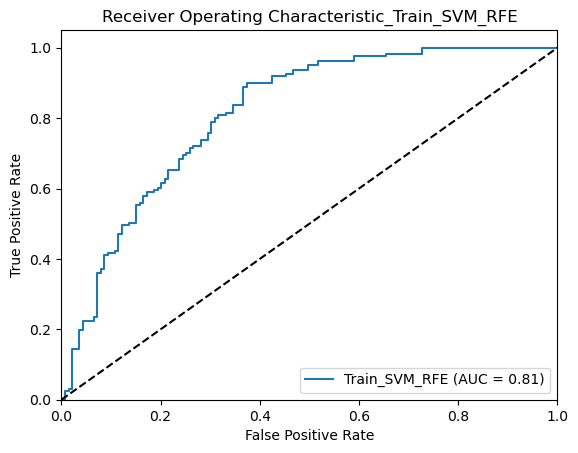


The metrics for the TEST data are:

Root Mean Squared Error (RMSE): 0.451377338550917
Mean Squared Error: 0.20374150175730912
Median Absolute Error (MedAE): 0.35246503090930814
Mean Absolute Error (MAE): 0.37571746495770325
R^2 Score: 0.18372795770308825
Explained Variance Score: 0.197802607950467
AUC: 0.7606837606837608


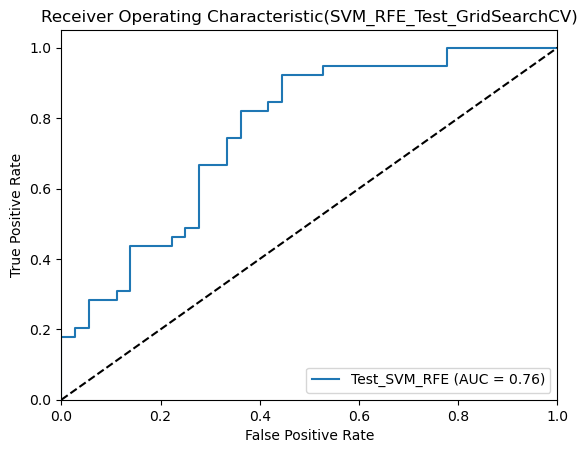

In [55]:
# Split the data into features (X) and target variable (y)
X = input1_encoded[selected_features]
y = input1_encoded['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an SVM regression model
svm = SVR()

# Print the model parameters
print("Model Parameters:", svm.get_params())
print()

# Train the model
svm.fit(X_train, y_train)

# Calculate metrics for the training data
y_train_pred = svm.predict(X_train)

rmse_train_SelectFeaturesSVM = np.sqrt(mean_squared_error(y_train, y_train_pred))
mse_train_SelectFeaturesSVM = mean_squared_error(y_train, y_train_pred)
mae_train_SelectFeaturesSVM = mean_absolute_error(y_train, y_train_pred)
r2_train_SelectFeaturesSVM = r2_score(y_train, y_train_pred)
evs_train_SelectFeaturesSVM = explained_variance_score(y_train, y_train_pred)
medae_train_SelectFeaturesSVM = median_absolute_error(y_train, y_train_pred)
auc_train_SelectFeaturesSVM = roc_auc_score(y_train, y_train_pred)
fpr_train_SelectFeaturesSVM, tpr_train_SelectFeaturesSVM, thresholds_train_SelectFeaturesSVM = roc_curve(y_train, y_train_pred)

print('\nThe thresholds for Train data are:',thresholds_train_SelectFeaturesSVM)

# Print the metrics for training data
print('\nThe metrics for the TRAIN data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_train_SelectFeaturesSVM)
print("Mean Squared Error:", mse_train_SelectFeaturesSVM)
print("Median Absolute Error (MedAE):", medae_train_SelectFeaturesSVM)
print("Mean Absolute Error (MAE):", mae_train_SelectFeaturesSVM)
print("R^2 Score:", r2_train_SelectFeaturesSVM)
print("Explained Variance Score:", evs_train_SelectFeaturesSVM)
print("AUC:", auc_train_SelectFeaturesSVM)

# Plot ROC Curve for training data
plt.figure()
plt.plot(fpr_train_SelectFeaturesSVM, tpr_train_SelectFeaturesSVM, label='Train_SVM_RFE (AUC = %0.2f)' % auc_train_SelectFeaturesSVM)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic_Train_SVM_RFE')
plt.legend(loc='lower right')
plt.show()

# Predict on the test set
y_pred = svm.predict(X_test)

# Calculate metrics of TEST data
rmse_SelectFeaturesSVM = np.sqrt(mean_squared_error(y_test, y_pred))
mse_SelectFeaturesSVM = mean_squared_error(y_test, y_pred)
mae_SelectFeaturesSVM = mean_absolute_error(y_test, y_pred)
r2_SelectFeaturesSVM = r2_score(y_test, y_pred)
evs_SelectFeaturesSVM = explained_variance_score(y_test, y_pred)
medae_SelectFeaturesSVM = median_absolute_error(y_test, y_pred)
fpr_SelectFeaturesSVM, tpr_SelectFeaturesSVM, thresholds_SelectFeaturesSVM = roc_curve(y_test, y_pred)
auc_SelectFeaturesSVM = roc_auc_score(y_test, y_pred)

# # Calculate VIF and TOL
# vif_SelectFeaturesSVM = pd.DataFrame()
# vif_SelectFeaturesSVM["Feature"] = X_train.columns
# vif_SelectFeaturesSVM["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
# vif_SelectFeaturesSVM["TOL"] = 1 / vif_SelectFeaturesSVM["VIF"]

# Print the metrics, VIF, and TOL
print('\nThe metrics for the TEST data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_SelectFeaturesSVM)
print("Mean Squared Error:", mse_SelectFeaturesSVM)
print("Median Absolute Error (MedAE):", medae_SelectFeaturesSVM)
print("Mean Absolute Error (MAE):", mae_SelectFeaturesSVM)
print("R^2 Score:", r2_SelectFeaturesSVM)
print("Explained Variance Score:", evs_SelectFeaturesSVM)
print("AUC:", auc_SelectFeaturesSVM)
# print("\nVariance Inflation Factor (VIF) and Tolerance (TOL):")
# print(vif_SelectFeaturesSVM)

# Plot ROC Curve
plt.figure()
plt.plot(fpr_SelectFeaturesSVM, tpr_SelectFeaturesSVM, label='Test_SVM_RFE (AUC = %0.2f)' % auc_SelectFeaturesSVM)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic(SVM_RFE_Test_GridSearchCV)')
plt.legend(loc='lower right')
plt.show()

In [56]:
# # Save the trained model
# joblib.dump(svm, 'SVM_RFE_SelectedFeatures.joblib')

#### Modeling using GridSearchCrossValidation method

The best parameters are:  {'C': 0.8, 'epsilon': 0.3, 'kernel': 'rbf'}

The thresholds for Train data are: [ 1.86111563  0.86111563  0.78808565  0.78776457  0.78496958  0.78320677
  0.73914975  0.73869219  0.73141917  0.7310342   0.72270784  0.72152221
  0.71763938  0.7115628   0.70753372  0.70743038  0.69956819  0.69543291
  0.69126599  0.68891341  0.68530122  0.68405738  0.67797781  0.67761962
  0.6766342   0.6735921   0.66887983  0.65873004  0.65826472  0.65475835
  0.65429717  0.65166522  0.64758434  0.64696489  0.64423263  0.63805165
  0.63533144  0.63482422  0.633375    0.63307523  0.63248384  0.62972106
  0.62812032  0.62736909  0.6257427   0.6243778   0.62384559  0.62113797
  0.61866783  0.61560407  0.6118925   0.61127524  0.60546175  0.60430322
  0.60299327  0.6015355   0.60138891  0.59963791  0.59776294  0.59619201
  0.59615728  0.59572382  0.59008946  0.58788003  0.58685365  0.58582027
  0.58287475  0.58109367  0.57809215  0.57284033  0.56527201  0.56468574
  0.56098349  0.55

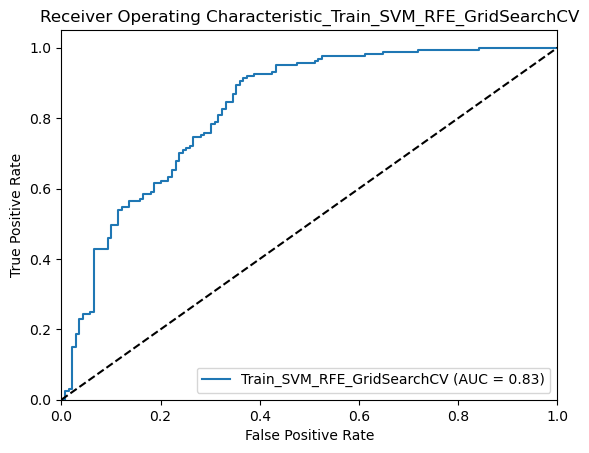


The metrics for the TEST data are:

Root Mean Squared Error (RMSE): 0.4371102359106241
Mean Squared Error: 0.19106535833784147
Median Absolute Error (MedAE): 0.3996676091401185
Mean Absolute Error (MAE): 0.4077894607060614
R^2 Score: 0.23451378871057083
Explained Variance Score: 0.2345190715083152
AUC: 0.777065527065527


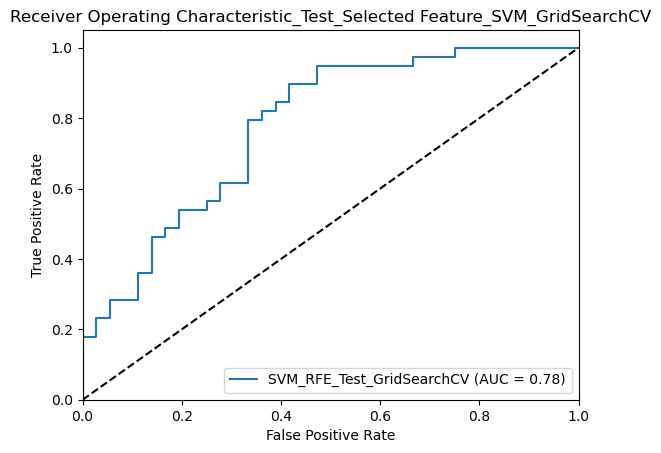

In [57]:
# Split the data into features (X) and target variable (y)
X = input1_encoded[selected_features]
y = input1_encoded['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1,0.01, 0.02, 0.2, 0.05, 0.5, 0.6, 0.7, 0.8, 1],
    'epsilon': [0.1, 0.01, 0.15, 0.2, 0.3, 0.4, 0.5],
#     'kernel': ['linear', 'rbf', 'poly']
    'kernel': ['rbf', 'poly']  
}

# Create the SVM regression model
svm_model = SVR()

# Create the GridSearchCV object
grid_search = GridSearchCV(svm_model, param_grid, scoring='neg_mean_squared_error', cv=5)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Get the best parameter combination found by GridSearchCV
best_params = grid_search.best_params_
print('The best parameters are: ',best_params)

# Create the SVM regression model with the best parameters
best_svm_model = SVR(**best_params)

# Train the model
best_svm_model.fit(X_train, y_train)

# Calculate metrics for the training data
y_train_pred = best_svm_model.predict(X_train)

rmse_train_SelectFeaturesSVM_GridSearchCV = np.sqrt(mean_squared_error(y_train, y_train_pred))
mse_train_SelectFeaturesSVM_GridSearchCV = mean_squared_error(y_train, y_train_pred)
mae_train_SelectFeaturesSVM_GridSearchCV = mean_absolute_error(y_train, y_train_pred)
r2_train_SelectFeaturesSVM_GridSearchCV = r2_score(y_train, y_train_pred)
evs_train_SelectFeaturesSVM_GridSearchCV = explained_variance_score(y_train, y_train_pred)
medae_train_SelectFeaturesSVM_GridSearchCV = median_absolute_error(y_train, y_train_pred)
auc_train_SelectFeaturesSVM_GridSearchCV = roc_auc_score(y_train, y_train_pred)
fpr_train_SelectFeaturesSVM_GridSearchCV, tpr_train_SelectFeaturesSVM_GridSearchCV, thresholds_train_SelectFeaturesSVM_GridSearchCV = roc_curve(y_train, y_train_pred)

print('\nThe thresholds for Train data are:',thresholds_train_SelectFeaturesSVM_GridSearchCV)

# Print the metrics for training data
print('\nThe metrics for the TRAIN data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_train_SelectFeaturesSVM_GridSearchCV)
print("Mean Squared Error:", mse_train_SelectFeaturesSVM_GridSearchCV)
print("Median Absolute Error (MedAE):", medae_train_SelectFeaturesSVM_GridSearchCV)
print("Mean Absolute Error (MAE):", mae_train_SelectFeaturesSVM_GridSearchCV)
print("R^2 Score:", r2_train_SelectFeaturesSVM_GridSearchCV)
print("Explained Variance Score:", evs_train_SelectFeaturesSVM_GridSearchCV)
print("AUC:", auc_train_SelectFeaturesSVM_GridSearchCV)

# Plot ROC Curve for training data
plt.figure()
plt.plot(fpr_train_SelectFeaturesSVM_GridSearchCV, tpr_train_SelectFeaturesSVM_GridSearchCV, label='Train_SVM_RFE_GridSearchCV (AUC = %0.2f)' % auc_train_SelectFeaturesSVM_GridSearchCV)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic_Train_SVM_RFE_GridSearchCV')
plt.legend(loc='lower right')
plt.show()

# Predict on the test set
y_pred = best_svm_model.predict(X_test)

# Calculate metrics
rmse_SelectFeaturesSVM_GridSearchCV = np.sqrt(mean_squared_error(y_test, y_pred))
mse_SelectFeaturesSVM_GridSearchCV = mean_squared_error(y_test, y_pred)
mae_SelectFeaturesSVM_GridSearchCV = mean_absolute_error(y_test, y_pred)
r2_SelectFeaturesSVM_GridSearchCV = r2_score(y_test, y_pred)
evs_SelectFeaturesSVM_GridSearchCV = explained_variance_score(y_test, y_pred)
medae_SelectFeaturesSVM_GridSearchCV = median_absolute_error(y_test, y_pred)
fpr_SelectFeaturesSVM_GridSearchCV, tpr_SelectFeaturesSVM_GridSearchCV, thresholds_SelectFeaturesSVM_GridSearchCV = roc_curve(y_test, y_pred)
auc_SelectFeaturesSVM_GridSearchCV = roc_auc_score(y_test, y_pred)

# # Calculate VIF and TOL
# vif_SelectFeaturesSVM_GridSearchCV = pd.DataFrame()
# vif_SelectFeaturesSVM_GridSearchCV["Feature"] = X_train.columns
# vif_SelectFeaturesSVM_GridSearchCV["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
# vif_SelectFeaturesSVM_GridSearchCV["TOL"] = 1 / vif_SelectFeaturesSVM_GridSearchCV["VIF"]

# Print the metrics, VIF, and TOL
print('\nThe metrics for the TEST data are:\n')
print("Root Mean Squared Error (RMSE):", rmse_SelectFeaturesSVM_GridSearchCV)
print("Mean Squared Error:", mse_SelectFeaturesSVM_GridSearchCV)
print("Median Absolute Error (MedAE):", medae_SelectFeaturesSVM_GridSearchCV)
print("Mean Absolute Error (MAE):", mae_SelectFeaturesSVM_GridSearchCV)
print("R^2 Score:", r2_SelectFeaturesSVM_GridSearchCV)
print("Explained Variance Score:", evs_SelectFeaturesSVM_GridSearchCV)
print("AUC:", auc_SelectFeaturesSVM_GridSearchCV)
# print("\nVariance Inflation Factor (VIF) and Tolerance (TOL):")
# print(vif_SelectFeaturesSVM_GridSearchCV)

# Plot ROC Curve
plt.figure()
plt.plot(fpr_SelectFeaturesSVM_GridSearchCV, tpr_SelectFeaturesSVM_GridSearchCV, label='SVM_RFE_Test_GridSearchCV (AUC = %0.2f)' % auc_SelectFeaturesSVM_GridSearchCV)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic_Test_Selected Feature_SVM_GridSearchCV')
plt.legend(loc='lower right')
plt.show()

In [58]:
# # Save the best model
# joblib.dump(best_svm_model, 'SVM_RFE_SelectedFeatures_GridSearchCV.joblib')

## Accuracy Assessment and ROC curve

### Metrics for TRAIN dataset 

In [61]:
# Create a dictionary to store the model names and their respective metrics of TRAIN data
model_metrics_train= {
    'Model': ['RandomForest_AllFeatures','RandomForest_SelectedFeatures', 'RandomForest_SelectedFeatures_GridSearchCV', 'XGBoost_SelectedFeatures','XGBoost_SelectedFeatures_GridSearchCV', 'SVM_SelectedFeatures','SVM_SelectedFeatures_GridSearchCV'],
    'RMSE': ['%.2f' %rmse_train_AllFeatRF,'%.2f' %rmse_train_SelectFeatRF,'%.2f' % rmse_train_SelectFeatRF_GridSearchCV,'%.2f' %rmse_train_SelectFeatXGBoost, '%.2f' %rmse_train_SelectFeatXGBoost_GridSearch, '%.2f' %rmse_train_SelectFeaturesSVM, '%.2f' %rmse_train_SelectFeaturesSVM_GridSearchCV],
    'MSE': ['%.2f' %mse_train_AllFeatRF,'%.2f' %mse_train_SelectFeatRF, '%.2f' % mse_train_SelectFeatRF_GridSearchCV , '%.2f' %mse_train_SelectFeatXGBoost, '%.2f' %mse_train_SelectFeatXGBoost_GridSearch, '%.2f' %mse_train_SelectFeaturesSVM, '%.2f' %mse_train_SelectFeaturesSVM_GridSearchCV],
    'MedAE': ['%.2f' %medae_train_AllFeatRF,'%.2f' %medae_train_SelectFeatRF, '%.2f' %medae_train_SelectFeatRF_GridSearchCV,'%.2f' %medae_train_SelectFeatXGBoost, '%.2f' %medae_train_SelectFeatXGBoost_GridSearch, '%.2f' %medae_train_SelectFeaturesSVM, '%.2f' %medae_train_SelectFeaturesSVM_GridSearchCV],
    'MAE': ['%.2f' %mae_train_AllFeatRF,'%.2f' %mae_train_SelectFeatRF,'%.2f' %mae_train_SelectFeatRF_GridSearchCV , '%.2f' %mae_train_SelectFeatXGBoost, '%.2f' %mae_train_SelectFeatXGBoost_GridSearch, '%.2f' %mae_train_SelectFeaturesSVM, '%.2f' %mae_train_SelectFeaturesSVM_GridSearchCV],
    'R^2': ['%.2f' %r2_train_AllFeatRF,'%.2f' %r2_train_SelectFeatRF,'%.2f' %r2_train_SelectFeatRF_GridSearchCV , '%.2f' %r2_train_SelectFeatXGBoost, '%.2f' %r2_train_SelectFeatXGBoost_GridSearch, '%.2f' %r2_train_SelectFeaturesSVM, '%.2f' %r2_train_SelectFeaturesSVM_GridSearchCV],
    'Explained Variance': ['%.2f' %evs_train_AllFeatRF,'%.2f' %evs_train_SelectFeatRF, '%.2f' %evs_train_SelectFeatRF_GridSearchCV, '%.2f' %evs_train_SelectFeatXGBoost, '%.2f' %evs_train_SelectFeatXGBoost_GridSearch, '%.2f' %evs_train_SelectFeaturesSVM, '%.2f' %evs_train_SelectFeaturesSVM_GridSearchCV],
    'AUC': ['%.2f' %auc_train_AllFeatRF,'%.2f' %auc_train_SelectFeatRF, '%.2f' %auc_train_SelectFeatRF_GridSearchCV, '%.2f' %auc_train_SelectFeatXGBoost, '%.2f' %auc_train_SelectFeatXGBoost_GridSearch, '%.2f' %auc_train_SelectFeaturesSVM, '%.2f' %auc_train_SelectFeaturesSVM_GridSearchCV],
}
# Create a DataFrame from the model metrics dictionary
metrics_df_train = pd.DataFrame(model_metrics_train)

# Print the table
print('The metrics for the TRAIN data is :')
metrics_df_train

The metrics for the TRAIN data is :


,Model,RMSE,MSE,MedAE,MAE,R^2,Explained Variance,AUC
0,RandomForest_AllFeatures,0.17,0.03,0.13,0.15,0.89,0.89,1.00
1,RandomForest_SelectedFeatures,0.17,0.03,0.13,0.14,0.89,0.89,1.00
2,RandomForest_SelectedFeatures_GridSearchCV,0.16,0.03,0.14,0.15,0.89,0.89,1.00
3,XGBoost_SelectedFeatures,0.00,0.00,0.00,0.00,1.00,1.00,1.00
4,XGBoost_SelectedFeatures_GridSearchCV,0.02,0.00,0.01,0.01,1.00,1.00,1.00
5,SVM_SelectedFeatures,0.43,0.19,0.26,0.34,0.25,0.30,0.81
6,SVM_SelectedFeatures_GridSearchCV,0.42,0.18,0.37,0.39,0.28,0.28,0.83


### Metrics for TEST dataset

In [62]:
# Create a dictionary to store the model names and their respective metrics of TEST data
model_metrics_test = {
    'Model': ['RandomForest_AllFeatures','RandomForest_SelectedFeatures', 'RandomForest_SelectedFeatures_GridSearchCV', 'XGBoost_SelectedFeatures','XGBoost_SelectedFeatures_GridSearchCV', 'SVM_SelectedFeatures','SVM_SelectedFeatures_GridSearchCV'],
    'RMSE': ['%.2f' %rmse_AllFeatRF,'%.2f' %rmse_SelectFeatRF,'%.2f' % rmse_SelectFeatRF_GridSearchCV,'%.2f' %rmse_SelectFeatXGBoost, '%.2f' %rmse_SelectFeatXGBoost_GridSearch, '%.2f' %rmse_SelectFeaturesSVM, '%.2f' %rmse_SelectFeaturesSVM_GridSearchCV],
    'MSE': ['%.2f' %mse_AllFeatRF,'%.2f' %mse_SelectFeatRF, '%.2f' % mse_SelectFeatRF_GridSearchCV , '%.2f' %mse_SelectFeatXGBoost, '%.2f' %mse_SelectFeatXGBoost_GridSearch, '%.2f' %mse_SelectFeaturesSVM, '%.2f' %mse_SelectFeaturesSVM_GridSearchCV],
    'MedAE': ['%.2f' %medae_AllFeatRF,'%.2f' %medae_SelectFeatRF, '%.2f' %medae_SelectFeatRF_GridSearchCV,'%.2f' %medae_SelectFeatXGBoost, '%.2f' %medae_SelectFeatXGBoost_GridSearch, '%.2f' %medae_SelectFeaturesSVM, '%.2f' %medae_SelectFeaturesSVM_GridSearchCV],
    'MAE': ['%.2f' %mae_AllFeatRF,'%.2f' %mae_SelectFeatRF,'%.2f' %mae_SelectFeatRF_GridSearchCV , '%.2f' %mae_SelectFeatXGBoost, '%.2f' %mae_SelectFeatXGBoost_GridSearch, '%.2f' %mae_SelectFeaturesSVM, '%.2f' %mae_SelectFeaturesSVM_GridSearchCV],
    'R^2': ['%.2f' %r2_AllFeatRF,'%.2f' %r2_SelectFeatRF,'%.2f' %r2_SelectFeatRF_GridSearchCV , '%.2f' %r2_SelectFeatXGBoost, '%.2f' %r2_SelectFeatXGBoost_GridSearch, '%.2f' %r2_SelectFeaturesSVM, '%.2f' %r2_SelectFeaturesSVM_GridSearchCV],
    'Explained Variance': ['%.2f' %evs_AllFeatRF,'%.2f' %evs_SelectFeatRF, '%.2f' %evs_SelectFeatRF_GridSearchCV, '%.2f' %evs_SelectFeatXGBoost, '%.2f' %evs_SelectFeatXGBoost_GridSearch, '%.2f' %evs_SelectFeaturesSVM, '%.2f' %evs_SelectFeaturesSVM_GridSearchCV],
    'AUC': ['%.2f' %auc_AllFeatRF,'%.2f' %auc_SelectFeatRF, '%.2f' %auc_SelectFeatRF_GridSearchCV, '%.2f' %auc_SelectFeatXGBoost, '%.2f' %auc_SelectFeatXGBoost_GridSearch, '%.2f' %auc_SelectFeaturesSVM, '%.2f' %auc_SelectFeaturesSVM_GridSearchCV],
}

# Create a DataFrame from the model metrics dictionary
metrics_df_test = pd.DataFrame(model_metrics_test)

# Print the table
print('The metrics for the TEST data is :')
metrics_df_test

The metrics for the TEST data is :


,Model,RMSE,MSE,MedAE,MAE,R^2,Explained Variance,AUC
0,RandomForest_AllFeatures,0.44,0.19,0.37,0.40,0.23,0.23,0.77
1,RandomForest_SelectedFeatures,0.44,0.19,0.36,0.38,0.24,0.24,0.78
2,RandomForest_SelectedFeatures_GridSearchCV,0.42,0.18,0.36,0.38,0.29,0.29,0.82
3,XGBoost_SelectedFeatures,0.46,0.21,0.27,0.36,0.15,0.16,0.76
4,XGBoost_SelectedFeatures_GridSearchCV,0.46,0.21,0.27,0.36,0.15,0.16,0.77
5,SVM_SelectedFeatures,0.45,0.20,0.35,0.38,0.18,0.20,0.76
6,SVM_SelectedFeatures_GridSearchCV,0.44,0.19,0.40,0.41,0.23,0.23,0.78


### ROC Curve

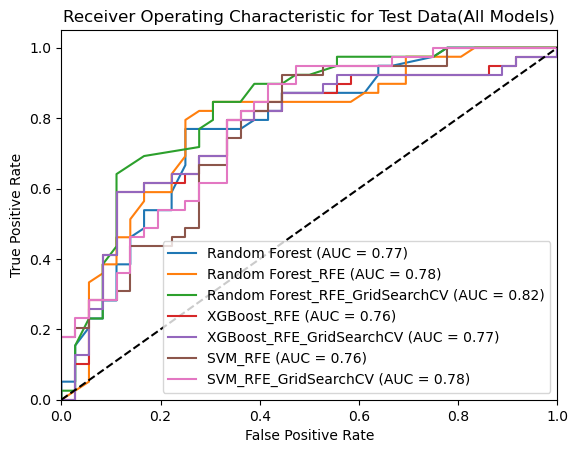

In [63]:
# Plot ROC Curve
plt.figure()
plt.plot(fpr_AllFeatRF, tpr_AllFeatRF, label='Random Forest (AUC = %0.2f)' % auc_AllFeatRF)
plt.plot(fprSelectFeatRF, tprSelectFeatRF, label='Random Forest_RFE (AUC = %0.2f)' % auc_SelectFeatRF)
plt.plot(fpr_SelectFeatRF_GridSearchCV, tpr_SelectFeatRF_GridSearchCV, label='Random Forest_RFE_GridSearchCV (AUC = %0.2f)' % auc_SelectFeatRF_GridSearchCV)

plt.plot(fpr_SelectFeatXGBoost, tpr_SelectFeatXGBoost, label='XGBoost_RFE (AUC = %0.2f)' % auc_SelectFeatXGBoost)
plt.plot(fpr_SelectFeatXGBoost_GridSearch, tpr_SelectFeatXGBoost_GridSearch, label='XGBoost_RFE_GridSearchCV (AUC = %0.2f)' % auc_SelectFeatXGBoost_GridSearch)

plt.plot(fpr_SelectFeaturesSVM, tpr_SelectFeaturesSVM, label='SVM_RFE (AUC = %0.2f)' % auc_SelectFeaturesSVM)
plt.plot(fpr_SelectFeaturesSVM_GridSearchCV, tpr_SelectFeaturesSVM_GridSearchCV, label='SVM_RFE_GridSearchCV (AUC = %0.2f)' % auc_SelectFeaturesSVM_GridSearchCV)


plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Test Data(All Models)')
plt.legend(loc='lower right')
plt.show()


# Prediction

## Attempt 1 (with Raster image inputs)

In [267]:
# # Define the spatial information of the target area
# xmin = 624360
# xmax = 657515
# ymin = 3092605
# ymax = 3121170
# pixel_width = 5  # Specify the pixel width in meters
# pixel_height = 5  # Specify the pixel height in meters
# target_crs = CRS.from_epsg(32644)  # Specify the spatial reference system (SRS) of the target area as EPSG 32644

# # Create an empty grid with NaN values
# grid_width_no = int((xmax - xmin) / pixel_width)
# grid_height_no = int((ymax - ymin) / pixel_height)
# grid_shape_no = (grid_height_no, grid_width_no)
# grid_data_no = np.full(grid_shape_no, np.nan)

# # Create a raster file with the grid data and spatial information
# with rasterio.open('prediction_grid_RF_RFE_GridSearchCV.tif', 'w', driver='GTiff', height=grid_height_no,
#                    width=grid_width_no, count=1, dtype=grid_data_no.dtype, crs=target_crs,
#                    transform=from_origin(xmin, ymax, pixel_width, pixel_height)) as dst:
#     dst.write(grid_data_no, 1)  # Write the grid data to the raster file

# # Load the trained Random Forest model
# model = joblib.load('RF_RFE_GridSearchCV.joblib')

# # feature1 = r'D:\HFT\3rd semester\THESIS\JUPYTER_NOTEBOOK\LabelEncodingRasters\Geology.tif'
# feature2 = r'D:\HFT\3rd semester\THESIS\JUPYTER_NOTEBOOK\LabelEncodingRasters\LULC.tif'
# feature3 = r'D:\HFT\3rd semester\THESIS\JUPYTER_NOTEBOOK\LabelEncodingRasters\SoilOrder.tif'
# feature4 = r'D:\HFT\3rd semester\THESIS\JUPYTER_NOTEBOOK\LabelEncodingRasters\SoilTexture.tif'
# feature5 = r'D:\HFT\3rd semester\THESIS\Data\NDVI\NDVIMosaicAoI5m.tif'
# feature6 = r'D:\HFT\3rd semester\THESIS\Data\Rainfall\AoIRainfallUTM44Buffer2km.tif'
# feature7 = r'D:\HFT\3rd semester\THESIS\Data\Slope\TopoSlope5m.tif'
# feature8 = r'D:\HFT\3rd semester\THESIS\Data\DEM\AoIDEM5m_Fill.sdat'
# feature9 = r'D:\HFT\3rd semester\THESIS\Data\TpographicalPositioningIndex\TPI.tif'
# feature10 = r'D:\HFT\3rd semester\THESIS\Data\DistanceToRiver\CliipedEulideanDistanceRiver.tif'
# feature11 = r'D:\HFT\3rd semester\THESIS\Data\TopographicWetnessIndex_TWI\TWI.tif'
# feature12 = r'D:\HFT\3rd semester\THESIS\Data\StreamPowerIndex_SPI\SPI.tif'
# feature13 = r'D:\HFT\3rd semester\THESIS\Data\DrainageDensity\Interpolation_IDW\AoI_DrainageDensity5m_IDW_2by2kmgrid.tif'
# feature14 = r'D:\HFT\3rd semester\THESIS\Data\DistanceToRoad\DistToRoad.tif'

# # List of feature raster paths
# feature_raster_paths = [feature2, feature3, feature4, feature5, feature6, feature7, feature8,
#                         feature9, feature10, feature11, feature12, feature13, feature14]

# ################Definition of the function extract_features_from_rasters(feature_raster_paths, grid_raster_path)################

# def extract_features_from_rasters(raster_paths, grid_path):
#     features = []
#     for raster_path in raster_paths:
#         with rasterio.open(raster_path) as src:
#             # Read the raster data and resample it to match the grid size
#             raster_data = src.read(1, out_shape=grid_shape_no)
#             features.append(raster_data)
#     return np.vstack(features)[:13]

# ################################################################################################################################

# # Extract features from the grid using multiple feature rasters
# features = extract_features_from_rasters(feature_raster_paths, 'prediction_grid_RF_RFE_GridSearchCV.tif')  # Implement this function to extract features

# # Make predictions using the trained model
# predictions = model.predict(np.vstack(features))

# # Open the grid raster file
# with rasterio.open('prediction_grid_RF_RFE_GridSearchCV.tif', 'r+') as src:
#     # Write the predicted values to the grid raster
#     src.write(predictions.reshape(grid_shape_no), 1)

# # Save the modified grid raster with the spatial reference system
# with rasterio.open('prediction_grid_RF_RFE_GridSearchCV.tif', 'w', driver='GTiff', height=grid_height_no,
#                    width=grid_width_no, count=1, dtype=grid_data_no.dtype, crs=target_crs,
#                    transform=from_origin(xmin, ymax, pixel_width, pixel_height)) as dst:
#     dst.write(predictions.reshape(grid_shape_no), 1)  # Write the predicted values to the raster file

## Attempt 2 with dbf Prediction file

### Loading Prediction Input File

In [268]:
# Read the DBF file using dbfread
table = DBF('Raster10mExtent_Points.dbf')

# Convert the DBF data to a DataFrame
tabledf= pd.DataFrame(iter(table))
print('The dimesnsion of the Prediction Input data is: ', tabledf.shape)

# # Combine the two DataFrames
# combined_df = pd.concat([df1, df2], ignore_index=True)

sample1 = tabledf.head(500)
sample1

The dimesnsion of the Prediction Input data is:  (5258486, 16)


,pointid,grid_code,SoilTextur,SoilOrder,Geology,LULC,NDVI,Rainfall,SlopeDeg,DEM,TPI,DistToRive,TWI,SPI,DistToRoad,DrDensity
0,5157653,68,4,2,3,1,0.603799,1674.69,-9999.0000,946.099,-3.880920,1180.100,5.41125,-9999.000000,1546.29,3281.84
1,5157654,143,4,2,3,1,0.589548,1674.74,-9999.0000,946.988,-3.158200,1176.400,5.19104,-0.578458,1544.47,3282.79
2,5157655,112,4,2,3,1,0.647056,1674.79,-9999.0000,948.233,-2.095280,1172.790,5.92513,-0.030615,1542.73,3284.90
3,5157656,112,4,2,3,1,0.628727,1674.84,-9999.0000,949.361,-1.151120,1169.240,4.20001,-1.889780,1541.04,3288.12
4,5157657,47,4,2,3,4,0.663714,1674.89,-9999.0000,950.416,-0.295105,1165.770,5.08236,-10.349000,1539.42,3292.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,5168778,20,4,2,3,4,0.695349,1681.16,23.7108,1015.660,4.513060,224.109,4.82307,1.288770,1740.81,4082.33
496,5168779,67,4,2,3,4,0.731277,1681.21,23.6694,1016.650,6.139590,216.391,4.73997,1.148800,1740.49,4073.85
497,5168780,51,4,2,3,4,0.727810,1681.27,23.6280,1017.630,7.782710,208.866,4.64833,0.989205,1740.23,4065.08
498,5168781,114,4,2,3,4,0.732024,1681.32,22.3080,1018.620,9.547790,201.556,3.67024,-0.265927,1740.03,4056.03


### SAMPLE : Data Cleaning and Prediction by removing Outliers

In [269]:
# # Remove +-9999 values from all features
# sample1_1 = sample1.replace([-9999, 9999], np.nan)

# # Drop rows with NaN values in all columns
# sample1_1_no9999Rows = sample1_1.dropna()
# print('The dimension of the table after dropping rows that has outlier +-9999 is: ', sample1_1_no9999Rows.shape)

# # Drop the columns that are not required
# sample1_2 = sample1_1_no9999Rows.drop(['pointid', 'grid_code', 'SoilTextur', 'SoilOrder', 'LULC', 'Geology'], axis=1)

# # Calculate z-scores for each numerical feature
# z_scores_table = pd.DataFrame(np.abs(stats.zscore(sample1_2)), columns=sample1_2.columns)

# # Set the threshold for outlier detection
# threshold = 3

# # Detect outliers for each numerical feature
# outliers = (z_scores_table > threshold)

# # Print the table of feature outliers and their z-scores
# for feature in outliers.columns:
#     feature_outliers = z_scores_table.loc[outliers[feature], feature]
#     if not feature_outliers.empty:
#         print(f"\nOutliers for feature in z-score for '{feature}':\n")
#         print(feature_outliers)
#         print(feature_outliers.shape)       
        
# # Filter out outliers from the z-scores table
# z_scores_table_no_outliersValues = z_scores_table.mask(outliers)
# print('\nTable with Z-score and after replacing outliers values with Nan: \n',z_scores_table_no_outliersValues)

# # Add back the dropped columns 
# sample1_2_allFields = pd.concat([sample1_1_no9999Rows[['pointid', 'grid_code', 'SoilTextur', 'SoilOrder', 'LULC', 'Geology']], z_scores_table_no_outliersValues], axis=1)

# print('\nTable after z-score scaling, outlier value change to Nan and adding back categorical features: \n',sample1_2_allFields)

# # Drop rows with NaN values
# z_scores_table_no_outliers_rows = sample1_2_allFields.dropna()
# print('\nTable after removing rows with outliers_Nan: \n',z_scores_table_no_outliers_rows)



# # Create a list of model names and corresponding class names
# model_names = ['RF_AllFeatures', 'RF_RFE_SelectedFeatures', 'RF_RFE_SelectedFeatures_GridSearchCV', 'XGBoost_RFE_SelectedFeatures', 'XGBoost_RFE_SelectedFeatures_GridSearchCV', 'SVM_RFE_SelectedFeatures', 'SVM_RFE_SelectedFeatures_GridSearchCV']
# class_names = ['RF', 'RF_RFE', 'RF_RFE_GridSearchCV', 'XGB_RFE', 'XGB_RFE_GridSearchCV', 'SVM_RFE', 'SVM_RFE_GridSearchCV']

# # Iterate through the models
# for i, model_name in enumerate(model_names):
#     # Load the model
#     model = joblib.load(f'{model_name}.joblib')
 
#     # Get the feature names from the training data
#     feature_names = model.feature_names_in_

#     # Select the relevant columns from the data
#     features = z_scores_table_no_outliers_rows[feature_names]

#     # Make predictions
#     predictions = model.predict(features)

#     # Add the predictions as a new column in the final DataFrame
#     z_scores_table_no_outliers_rows[class_names[i]] = predictions

# z_scores_table_no_outliers_rows

# # Save the final predictions as a CSV file
# # final_predictions.to_csv('FINAL_PREDICTIONS_SAMPLES.csv', index=False)


### AllPredictionInputData : Data Cleaning and Prediction by removing Outliers

In [64]:
# Remove +-9999 values from all features
sample1_1 = tabledf.replace([-9999, 9999], np.nan)

# Drop rows with NaN values in all columns
sample1_1_no9999Rows = sample1_1.dropna()
print('The dimension of the table after dropping rows that has outlier +-9999 is: ', sample1_1_no9999Rows.shape)

# Drop the columns that are not required
sample1_2 = sample1_1_no9999Rows.drop(['pointid', 'grid_code', 'SoilTextur', 'SoilOrder', 'LULC', 'Geology'], axis=1)

# Calculate z-scores for each numerical feature
z_scores_table = pd.DataFrame(np.abs(stats.zscore(sample1_2)), columns=sample1_2.columns)

# Set the threshold for outlier detection
threshold = 7

# Detect outliers for each numerical feature
outliers = (z_scores_table > threshold)

# Print the table of feature outliers and their z-scores
for feature in outliers.columns:
    feature_outliers = z_scores_table.loc[outliers[feature], feature]
    if not feature_outliers.empty:
        print(f"\nOutliers for feature in z-score for '{feature}':\n")
        print(feature_outliers)
        print(feature_outliers.shape)       
        
# Filter out outliers from the z-scores table
z_scores_table_no_outliersValues = z_scores_table.mask(outliers)
print('\nTable with Z-score and after replacing outliers values with Nan: \n',z_scores_table_no_outliersValues)

# Add back the dropped columns 
sample1_2_allFields = pd.concat([sample1_1_no9999Rows[['pointid', 'grid_code', 'SoilTextur', 'SoilOrder', 'LULC', 'Geology']], z_scores_table_no_outliersValues], axis=1)

print('\nTable after z-score scaling, outlier value change to Nan and adding back categorical features: \n',sample1_2_allFields)

# Drop rows with NaN values
z_scores_table_no_outliers_rows = sample1_2_allFields.dropna()
print('\nTable after removing rows with outliers_Nan: \n',z_scores_table_no_outliers_rows)



# Create a list of model names and corresponding class names
model_names = ['RF_AllFeatures', 'RF_RFE_SelectedFeatures', 'RF_RFE_SelectedFeatures_GridSearchCV', 'XGBoost_RFE_SelectedFeatures', 'XGBoost_RFE_SelectedFeatures_GridSearchCV', 'SVM_RFE_SelectedFeatures', 'SVM_RFE_SelectedFeatures_GridSearchCV']
class_names = ['RF', 'RF_RFE', 'RF_RFE_GridSearchCV', 'XGB_RFE', 'XGB_RFE_GridSearchCV', 'SVM_RFE', 'SVM_RFE_GridSearchCV']


# Iterate through the models
for i, model_name in enumerate(model_names):
    # Load the model
    model = joblib.load(f'{model_name}.joblib')
 
    # Get the feature names from the training data
    feature_names = model.feature_names_in_

    # Select the relevant columns from the data
    features = z_scores_table_no_outliers_rows[feature_names]

    # Make predictions
    predictions = model.predict(features)

    # Add the predictions as a new column in the final DataFrame
    z_scores_table_no_outliers_rows[class_names[i]] = predictions

z_scores_table_no_outliers_rows

NameError: name 'tabledf' is not defined

In [ ]:
# # Save the final predictions as a CSV file
# z_scores_table_no_outliers_rows.to_csv('FINAL_PREDICTIONS_AllModel_WithoutOUTLIERS_threshold3_7_10m_try.csv', index=False)
# print('Predictions Exported...')

### AllPredictionInputData : Data Cleaning and Prediction without removing Outliers

In [ ]:
# # Drop the columns that are not required
# sample1_2 = tabledf.drop(['pointid', 'grid_code', 'SoilTextur', 'SoilOrder', 'LULC', 'Geology'], axis=1)

# # Calculate z-scores for each numerical feature
# z_scores_table = pd.DataFrame(np.abs(stats.zscore(sample1_2)), columns=sample1_2.columns)

# # Add back the dropped columns 
# sample1_2_allFields = pd.concat([tabledf[['pointid', 'grid_code', 'SoilTextur', 'SoilOrder', 'LULC', 'Geology']], z_scores_table], axis=1)

# print('\nTable after z-score scaling and adding back categorical features: \n',sample1_2_allFields)

# # Create a list of model names and corresponding class names
# model_names = ['RF_AllFeatures', 'RF_RFE_SelectedFeatures', 'RF_RFE_SelectedFeatures_GridSearchCV', 'XGBoost_RFE_SelectedFeatures', 'XGBoost_RFE_SelectedFeatures_GridSearchCV', 'SVM_RFE_SelectedFeatures', 'SVM_RFE_SelectedFeatures_GridSearchCV']
# class_names = ['RF', 'RF_RFE', 'RF_RFE_GridSearchCV', 'XGB_RFE', 'XGB_RFE_GridSearchCV', 'SVM_RFE', 'SVM_RFE_GridSearchCV']

# # Iterate through the models
# for i, model_name in enumerate(model_names):
#     # Load the model
#     model = joblib.load(f'{model_name}.joblib')
 
#     # Get the feature names from the training data
#     feature_names = model.feature_names_in_

#     # Select the relevant columns from the data
#     features = sample1_2_allFields[feature_names]

#     # Make predictions
#     predictions = model.predict(features)

#     # Add the predictions as a new column in the final DataFrame
#     sample1_2_allFields[class_names[i]] = predictions

# sample1_2_allFields

In [ ]:
# # Save the final predictions as a CSV file
# sample1_2_allFields.to_csv('FINAL_PREDICTIONS_AllModel_WithOUTLIERS.csv', index=False)

# Confusion Matrix From GIS

In [ ]:
# csv_path = r'D:\HFT\3rd semester\THESIS\JUPYTER_NOTEBOOK\ACCIRACY ASSESSMENT\CM_data.csv'
# data_frame = pd.read_csv(csv_path)
# data_frame

In [ ]:
# # Assuming you have a DataFrame called 'data_frame' with two fields: 'actual' and 'predicted'
# actual_values = data_frame['GrndTruth']
# predicted_fields = ['RF_RF_G_CM', 'RF_RFE_CM', 'RF_CM', 'SVM_R_G_CM', 'XGB_R_G_CM', 'XGB_R_CM', 'SVM_RFE_CM']

# for field in predicted_fields:
#     predicted_values = data_frame[field]

#     # Create the confusion matrix
#     cm = confusion_matrix(actual_values, predicted_values)

#     # Calculate user accuracy (also known as recall or sensitivity)
#     user_accuracy = cm.diagonal() / cm.sum(axis=1)

#     # Calculate producer accuracy (also known as precision)
#     producer_accuracy = cm.diagonal() / cm.sum(axis=0)

#     # Calculate overall accuracy
#     overall_accuracy = cm.diagonal().sum() / cm.sum()

#     # Calculate kappa coefficient
#     kappa = cohen_kappa_score(actual_values, predicted_values)

#     # Create a DataFrame to display the results
#     results = pd.DataFrame({
#         'Labels': list(range(len(cm))),
#         'User Accuracy': user_accuracy,
#         'Producer Accuracy': producer_accuracy
#     })

#     # Add a row for overall accuracy
#     results.loc['Overall'] = ['', '', overall_accuracy]

#     # Print the table for the current predicted value
#     print('\nConfusion Matrix for', field)
#     print(results)

#     # Print kappa coefficient for the current predicted value
#     print("\nKappa Coefficient for", field, ":", kappa)
#     print("-" * 50)  # Separator line between tables
